# BU RISE Wind-Model Comparison Notebook

This notebook compares all active CPU and GPU wind models using the exact common eligible test rows shared by every model.

It supports:

- common wind-speed MAE and correlation;
- circular direction MAE above a configurable wind-speed threshold;
- balanced/hybrid model selection;
- pairwise model comparisons;
- predicted-versus-true scatterplots;
- direction-error distributions;
- direction MAE by wind-speed bin;
- per-flight comparisons;
- representative-flight time series;
- direction-confidence diagnostics.

The notebook automatically excludes archived folders whose names contain terms such as `incomplete`, `failed`, `backup`, or `old`.

## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Colab / Google Drive setup
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# Set this manually when you know the exact project folder.
# Example:
# PROJECT_ROOT_OVERRIDE = Path(
#     "/content/drive/MyDrive/BU-RISE/wind_ml_pipeline_12_models"
# )
PROJECT_ROOT_OVERRIDE = Path(
    r"C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models"
)

def find_project_root(start: Path | None = None) -> Path:
    if PROJECT_ROOT_OVERRIDE is not None:
        candidate = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if not (candidate / "src" / "final_analysis_utils.py").exists():
            raise FileNotFoundError(
                f"PROJECT_ROOT_OVERRIDE does not contain src/final_analysis_utils.py: {candidate}"
            )
        return candidate

    start = (start or Path.cwd()).resolve()
    local_candidates = [start, *start.parents]
    for candidate in local_candidates:
        if (
            (candidate / "src" / "final_analysis_utils.py").exists()
            and (candidate / "results" / "scc" / "baseline").exists()
        ):
            return candidate

    drive_root = Path("/content/drive/MyDrive")
    if drive_root.exists():
        matches = sorted(drive_root.rglob("src/final_analysis_utils.py"))
        valid_roots = [
            match.parent.parent
            for match in matches
            if (match.parent.parent / "results" / "scc" / "baseline").exists()
        ]
        if len(valid_roots) == 1:
            return valid_roots[0]
        if len(valid_roots) > 1:
            print("Multiple project roots were found:")
            for candidate in valid_roots:
                print("  ", candidate)
            raise RuntimeError(
                "Set PROJECT_ROOT_OVERRIDE near the top of this cell to the correct folder."
            )

    raise FileNotFoundError(
        "Could not locate the project root. Set PROJECT_ROOT_OVERRIDE to the folder "
        "that contains src/final_analysis_utils.py and results/scc/baseline."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "results" / "scc" / "baseline"
OUTPUT_DIR = PROJECT_ROOT / "results" / "scc" / "final_analysis"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from final_analysis_utils import (
    common_frames,
    compute_common_comparison,
    load_all_predictions,
    select_winners,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")


Project root: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models
Results dir:  C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\baseline
Output dir:   C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\scc\final_analysis


## 2. Analysis configuration

In [2]:
EXPECTED_MODELS = 12
DIRECTION_MIN_SPEED = 1.0
SPEED_WEIGHT = 0.50
DIRECTION_WEIGHT = 0.50
RANDOM_SEED = 42

# Change these later for focused plots.
SELECTED_MODEL = None
SELECTED_FLIGHT = None

print(
    f"Expected models: {EXPECTED_MODELS}\n"
    f"Direction metric threshold: true wind speed > {DIRECTION_MIN_SPEED:g} m/s\n"
    f"Balanced weights: speed={SPEED_WEIGHT:.2f}, direction={DIRECTION_WEIGHT:.2f}"
)

Expected models: 12
Direction metric threshold: true wind speed > 1 m/s
Balanced weights: speed=0.50, direction=0.50


## 2A. Combine the cleaned AMOVFLY flights

This cell combines every `*_cleaned.csv` file into one external-validation CSV while preserving each flight as a separate group. It excludes the cleaning report and logs automatically.

`Timestamp` may be empty; the inference code orders each flight with `Elapsed_s`.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# Change this path only when your cleaned folder is stored elsewhere.
CLEANED_FLIGHT_DIR = PROJECT_ROOT / "data" / "uploaded_secondary" / "cleaned_flights"
COMBINED_EXTERNAL_PATH = (
    PROJECT_ROOT / "data" / "secondary_amovfly_all_cleaned.csv"
)
COMBINED_EXTERNAL_PATH.parent.mkdir(parents=True, exist_ok=True)

if not CLEANED_FLIGHT_DIR.exists():
    raise FileNotFoundError(
        f"Cleaned-flight folder not found: {CLEANED_FLIGHT_DIR}"
    )

cleaned_files = sorted(
    path
    for path in CLEANED_FLIGHT_DIR.rglob("*_cleaned.csv")
    if path.name not in {"cleaning_report.csv", "download_manifest.csv"}
)

if not cleaned_files:
    raise FileNotFoundError(
        f"No *_cleaned.csv files were found below {CLEANED_FLIGHT_DIR}"
    )

frames_to_combine = []

for path in cleaned_files:
    frame = pd.read_csv(path, low_memory=False)

    # Use the filename when the file does not already contain a usable Flight_ID.
    fallback_flight_id = path.stem.removesuffix("_cleaned")
    if "Flight_ID" not in frame.columns:
        frame["Flight_ID"] = fallback_flight_id
    else:
        frame["Flight_ID"] = (
            frame["Flight_ID"]
            .astype("string")
            .replace({"": pd.NA, "nan": pd.NA, "<NA>": pd.NA})
            .fillna(fallback_flight_id)
        )

    frame["_Source_file"] = str(path.relative_to(CLEANED_FLIGHT_DIR))
    frames_to_combine.append(frame)

external_data = pd.concat(frames_to_combine, ignore_index=True, sort=False)

for column in [
    "Elapsed_s", "X", "Y", "Z", "Roll", "Pitch", "Yaw",
    "Wind_speed", "Wind_angle", "Battery_V", "Battery_C",
]:
    if column in external_data.columns:
        external_data[column] = pd.to_numeric(
            external_data[column], errors="coerce"
        )

if "Elapsed_s" in external_data.columns:
    external_data = (
        external_data
        .sort_values(["Flight_ID", "Elapsed_s"], kind="stable", na_position="last")
        .reset_index(drop=True)
    )

external_data.to_csv(COMBINED_EXTERNAL_PATH, index=False)

print(f"Cleaned files combined: {len(cleaned_files):,}")
print(f"Unique Flight_ID values: {external_data['Flight_ID'].nunique():,}")
print(f"Rows combined:          {len(external_data):,}")
print(f"Saved to:               {COMBINED_EXTERNAL_PATH}")

sanity_columns = [
    "Flight_ID", "Elapsed_s", "X", "Y", "Z", "Roll", "Pitch", "Yaw",
    "Wind_speed", "Wind_angle", "Battery_V", "Battery_C",
]
available_sanity_columns = [
    column for column in sanity_columns if column in external_data.columns
]

display(
    pd.DataFrame({
        "nonmissing": external_data[available_sanity_columns].notna().sum(),
        "percent_present": (
            external_data[available_sanity_columns]
            .notna()
            .mean()
            .mul(100)
            .round(2)
        ),
    })
)
display(external_data[available_sanity_columns].head())


Cleaned files combined: 172
Unique Flight_ID values: 171
Rows combined:          512,543
Saved to:               C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\data\secondary_amovfly_all_cleaned.csv


,nonmissing,percent_present
Flight_ID,512543,100.0000
Elapsed_s,512543,100.0000
X,512543,100.0000
Y,512543,100.0000
Z,512543,100.0000
Roll,512543,100.0000
Pitch,512543,100.0000
Yaw,512543,100.0000
Wind_speed,485907,94.8000
Wind_angle,485907,94.8000


,Flight_ID,Elapsed_s,X,Y,Z,Roll,Pitch,Yaw,Wind_speed,Wind_angle,Battery_V,Battery_C
0,UavG_P0A10VarS4_1,0.0000,-0.6704,-2.4668,1.3196,-0.0240,-0.0291,1.4502,0.7000,37.0000,16.5180,0.0000
1,UavG_P0A10VarS4_1,0.2000,-0.6673,-2.4726,1.3216,-0.0240,-0.0289,1.4503,0.7000,37.0000,16.5360,0.0000
2,UavG_P0A10VarS4_1,0.3800,-0.6623,-2.4786,1.3232,-0.0240,-0.0290,1.4503,0.7000,37.0000,16.5550,0.0000
3,UavG_P0A10VarS4_1,0.6000,-0.6586,-2.4850,1.3238,-0.0240,-0.0290,1.4503,0.7000,37.0000,16.5840,0.0000
4,UavG_P0A10VarS4_1,0.7800,-0.6555,-2.4921,1.3249,-0.0241,-0.0290,1.4504,0.7000,37.0000,16.6000,0.0000


In [4]:
TRAINED_RESULTS_ROOT = PROJECT_ROOT / "results" / "scc"

artifact_extensions = {
    ".joblib", ".pkl", ".pickle", ".pt", ".pth",
}

artifact_files = sorted(
    path
    for path in TRAINED_RESULTS_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in artifact_extensions
)

prediction_files = sorted(
    TRAINED_RESULTS_ROOT.rglob("test_predictions.csv")
)

print("Model artifacts found:", len(artifact_files))
for path in artifact_files:
    print("  ", path.relative_to(PROJECT_ROOT))

print("\nExisting trained prediction files:", len(prediction_files))
for path in prediction_files:
    print("  ", path.parent.relative_to(TRAINED_RESULTS_ROOT))


Model artifacts found: 22
   results\scc\baseline\cpu\1_extra_trees\wind_model.joblib
   results\scc\baseline\cpu\2_random_forest\wind_model.joblib
   results\scc\baseline\cpu\3_decision_tree\wind_model.joblib
   results\scc\baseline\cpu\4_ridge\wind_model.joblib
   results\scc\baseline\cpu\5_dummy\wind_model.joblib
   results\scc\baseline\cpu\6_xgboost\wind_model.joblib
   results\scc\baseline\cpu\7_lightgbm\wind_model.joblib
   results\scc\baseline\cpu\8_catboost\wind_model.joblib
   results\scc\baseline\gpu\1_mlp\wind_model.pt
   results\scc\baseline\gpu\2_lstm\wind_model.pt
   results\scc\baseline\gpu\3_tcn\wind_model.pt
   results\scc\baseline\gpu\4_transformer\wind_model.pt
   results\scc\direction_experiments\cpu\1_et_leaf3\wind_model.joblib
   results\scc\direction_experiments\cpu\2_et_leaf10\wind_model.joblib
   results\scc\direction_experiments\cpu\3_et_rf_hybrid\wind_model.joblib
   results\scc\direction_experiments\cpu\4_et_cat_hybrid\wind_model.joblib
   results\scc\direct

### Direction-label warning

AMOVFLY documents `wind_angle` as an angle **relative to the drone's flight direction**. Only treat its direction error as directly comparable to the primary dataset after confirming that the primary target uses the same reference frame, rotation sign, and “from”/“toward” convention. Wind-speed external validation can still be evaluated directly.


## 2B. Engineer the secondary data and run saved tabular models

This section uses the exact `add_engineered_features` function from `src/wind_core.py`, recovers each saved model's training feature order, runs prediction without fitting, and saves one external `test_predictions.csv` per model.

Start with `MODEL_NAMES = ["extra_trees"]`. Add the other `.joblib` tabular models only after Extra Trees succeeds. Neural `.pt` models require their architecture-specific loader and should be handled separately.


In [5]:
# ============================================================
# EXTERNAL INFERENCE FOR SAVED TABULAR MODELS
# No model fitting occurs anywhere in this cell.
# ============================================================

from pathlib import Path
import gc
import json
import re
from typing import Any

import joblib
import numpy as np
import pandas as pd

try:
    from wind_core import (
        add_engineered_features,
        build_direction_targets,
        modeled_to_absolute_angle,
        vectors_to_angle_and_confidence,
    )
except ImportError:
    from src.wind_core import (
        add_engineered_features,
        build_direction_targets,
        modeled_to_absolute_angle,
        vectors_to_angle_and_confidence,
    )


# ----------------------------
# User settings
# ----------------------------
EXTERNAL_DATA_PATH = COMBINED_EXTERNAL_PATH
TRAINED_RESULTS_DIR = PROJECT_ROOT / "results" / "scc"
EXTERNAL_RESULTS_DIR = PROJECT_ROOT / "results" / "external_amovfly"
EXTERNAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Start with one tabular model. Add the others only after this succeeds.
MODEL_NAMES = ["extra_trees"]

# Optional manual overrides. Usually leave these empty.
MODEL_ARTIFACTS: dict[str, Any] = {}
FEATURE_COLUMNS_OVERRIDE: dict[str, list[str]] = {}

CLIP_NEGATIVE_PREDICTED_SPEED = True


# ----------------------------
# Artifact and metadata helpers
# ----------------------------
def _normalise_token(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(value).lower()).strip("_")


def _find_run_directory(model_name: str) -> Path:
    token = _normalise_token(model_name)
    run_dirs = sorted({
        path.parent
        for path in TRAINED_RESULTS_DIR.rglob("test_predictions.csv")
    })
    matches = [
        path
        for path in run_dirs
        if token in _normalise_token(path.name)
        or token in _normalise_token(
            str(path.relative_to(TRAINED_RESULTS_DIR))
        )
    ]
    if not matches:
        raise FileNotFoundError(
            f"Could not find a trained result directory for {model_name!r} "
            f"below {TRAINED_RESULTS_DIR}."
        )

    # Prefer baseline runs over direction experiments for base model names.
    return min(
        matches,
        key=lambda path: (
            "direction_experiments" in _normalise_token(str(path)),
            len(path.parts),
            len(str(path)),
        ),
    )


def _candidate_artifact_files(run_dir: Path) -> list[Path]:
    extensions = {".joblib", ".pkl", ".pickle"}
    excluded_terms = {
        "prediction", "metric", "ranking", "comparison", "importance",
    }
    return [
        path
        for path in run_dir.rglob("*")
        if path.is_file()
        and path.suffix.lower() in extensions
        and not any(
            term in _normalise_token(path.name)
            for term in excluded_terms
        )
    ]


def _artifact_score(path: Path, model_name: str) -> tuple[int, int, str]:
    name = _normalise_token(path.stem)
    token = _normalise_token(model_name)
    score = 0
    if token in name:
        score += 40
    if "pipeline" in name:
        score += 35
    if "wind_model" in name or name == "model":
        score += 30
    if "model" in name:
        score += 20
    if any(
        term in name
        for term in ("scaler", "encoder", "preprocessor")
    ):
        score -= 50
    return (-score, len(path.parts), str(path))


def _load_one_artifact(path: Path) -> Any:
    return joblib.load(path, mmap_mode="r")


def _load_bundle(
    model_name: str,
    run_dir: Path,
) -> tuple[Any, list[Path]]:
    override = MODEL_ARTIFACTS.get(model_name)

    if override is not None:
        if isinstance(override, dict):
            paths = [Path(value) for value in override.values()]
            return {
                key: _load_one_artifact(Path(value))
                for key, value in override.items()
            }, paths
        path = Path(override)
        return _load_one_artifact(path), [path]

    candidates = _candidate_artifact_files(run_dir)
    if not candidates:
        raise FileNotFoundError(
            f"No tabular model artifact was found below {run_dir}."
        )

    chosen = sorted(
        candidates,
        key=lambda path: _artifact_score(path, model_name),
    )[0]
    return _load_one_artifact(chosen), [chosen]


def _recursive_lookup(
    obj: Any,
    keys: tuple[str, ...],
) -> Any:
    if isinstance(obj, dict):
        for key in keys:
            if key in obj and obj[key] is not None:
                return obj[key]
        for value in obj.values():
            if isinstance(value, dict):
                result = _recursive_lookup(value, keys)
                if result is not None:
                    return result
    return None


def _feature_columns_from_sidecars(
    paths: list[Path],
) -> list[str] | None:
    keys = (
        "feature_columns",
        "features",
        "input_features",
        "feature_names",
    )
    checked: set[Path] = set()

    for artifact_path in paths:
        for folder in (
            artifact_path.parent,
            artifact_path.parent.parent,
        ):
            if folder in checked or not folder.exists():
                continue
            checked.add(folder)

            for path in folder.glob("*.json"):
                try:
                    payload = json.loads(
                        path.read_text(encoding="utf-8")
                    )
                except Exception:
                    continue

                value = _recursive_lookup(payload, keys)
                if (
                    isinstance(value, (list, tuple))
                    and value
                    and all(isinstance(item, str) for item in value)
                ):
                    return list(value)

    return None


def _collect_predictors(
    obj: Any,
    prefix: str = "root",
) -> list[tuple[str, Any]]:
    found: list[tuple[str, Any]] = []

    if hasattr(obj, "predict") and callable(obj.predict):
        found.append((prefix, obj))
        return found

    if isinstance(obj, dict):
        for key, value in obj.items():
            found.extend(
                _collect_predictors(value, f"{prefix}.{key}")
            )

    elif isinstance(obj, (list, tuple)):
        for index, value in enumerate(obj):
            found.extend(
                _collect_predictors(value, f"{prefix}[{index}]")
            )

    return found


def _extract_feature_columns(
    model_name: str,
    bundle: Any,
    paths: list[Path],
) -> list[str]:
    if model_name in FEATURE_COLUMNS_OVERRIDE:
        return list(FEATURE_COLUMNS_OVERRIDE[model_name])

    keys = (
        "feature_columns",
        "features",
        "input_features",
        "feature_names",
    )

    value = _recursive_lookup(bundle, keys)
    if isinstance(value, (list, tuple, np.ndarray)) and len(value):
        return [str(item) for item in value]

    for _, predictor in _collect_predictors(bundle):
        names = getattr(predictor, "feature_names_in_", None)
        if names is not None and len(names):
            return [str(item) for item in names]

    sidecar_features = _feature_columns_from_sidecars(paths)
    if sidecar_features is not None:
        return sidecar_features

    raise ValueError(
        f"Could not recover the exact feature list for {model_name!r}. "
        "Do not use a numeric-column fallback; set FEATURE_COLUMNS_OVERRIDE "
        "from the saved training metadata."
    )


# ----------------------------
# Exact training feature engineering
# ----------------------------
def _run_training_feature_engineering(
    raw_data: pd.DataFrame,
) -> pd.DataFrame:
    data = raw_data.copy()
    data["_External_row_id"] = np.arange(len(data), dtype=np.int64)

    numeric_columns = [
        "Elapsed_s", "X", "Y", "Z", "Roll", "Pitch", "Yaw",
        "Wind_speed", "Wind_angle", "Battery_V", "Battery_C",
    ]
    for column in numeric_columns:
        if column in data.columns:
            data[column] = pd.to_numeric(
                data[column], errors="coerce"
            )

    if "Flight_ID" not in data.columns:
        raise KeyError("The external dataset has no Flight_ID column.")

    source = (
        data["Source_dataset"]
        .astype("string")
        .fillna("AMOVFLY")
        if "Source_dataset" in data.columns
        else pd.Series(
            "AMOVFLY",
            index=data.index,
            dtype="string",
        )
    )
    flight = (
        data["Flight_ID"]
        .astype("string")
        .fillna("missing_flight")
    )
    data["_Group_ID"] = source + "::" + flight

    sort_columns = ["_Group_ID"]
    if "Elapsed_s" in data.columns:
        sort_columns.append("Elapsed_s")

    data = data.sort_values(
        sort_columns,
        kind="stable",
        na_position="last",
    )

    result = add_engineered_features(data)

    if isinstance(result, pd.DataFrame):
        engineered = result
    elif isinstance(result, tuple):
        dataframes = [
            value for value in result
            if isinstance(value, pd.DataFrame)
        ]
        if not dataframes:
            raise TypeError(
                "add_engineered_features returned a tuple with no DataFrame."
            )
        engineered = dataframes[0]
    else:
        raise TypeError(
            "Unsupported add_engineered_features return type: "
            f"{type(result).__name__}"
        )

    if "_External_row_id" not in engineered.columns:
        raise KeyError(
            "The training feature function removed _External_row_id, "
            "so predictions cannot be aligned safely."
        )

    return (
        engineered
        .sort_values("_External_row_id", kind="stable")
        .reset_index(drop=True)
    )


def _prepare_model_matrix(
    engineered: pd.DataFrame,
    feature_columns: list[str],
) -> pd.DataFrame:
    missing = [
        column
        for column in feature_columns
        if column not in engineered.columns
    ]
    if missing:
        raise KeyError(
            "The local src/wind_core.py did not generate every feature "
            "required by the saved model. This usually means the local "
            "feature-engineering code differs from the SCC training version.\n"
            f"Missing features: {missing}"
        )

    return engineered.loc[:, feature_columns].copy()


# ----------------------------
# Saved tabular artifact interpretation
# ----------------------------
def _bundle_metadata(
    bundle: Any,
) -> tuple[dict[str, Any], dict[str, Any]]:
    """Read saved training arguments and feature metadata."""
    if not isinstance(bundle, dict):
        return {}, {}

    training_arguments = bundle.get("training_arguments", {})
    feature_metadata = bundle.get("feature_metadata", {})

    if not isinstance(training_arguments, dict):
        training_arguments = {}
    if not isinstance(feature_metadata, dict):
        feature_metadata = {}

    return training_arguments, feature_metadata


def _vectors_to_absolute_direction(
    direction_vectors: np.ndarray,
    bundle: Any,
    engineered: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, str]:
    """Convert saved direction-model outputs into absolute degrees."""
    vectors = np.asarray(direction_vectors, dtype=float)

    if vectors.ndim != 2 or vectors.shape[1] != 2:
        raise ValueError(
            "The direction model must return two columns "
            f"[sin, cos], but returned {vectors.shape}."
        )

    modeled_angle, confidence = vectors_to_angle_and_confidence(
        vectors
    )

    training_arguments, feature_metadata = _bundle_metadata(
        bundle
    )
    target_mode = str(
        training_arguments.get("direction_target", "absolute")
    )

    if target_mode == "absolute":
        return (
            np.asarray(modeled_angle, dtype=float) % 360.0,
            np.asarray(confidence, dtype=float),
            target_mode,
        )

    if "Yaw" not in engineered.columns:
        raise KeyError(
            "This saved model used a yaw-relative direction target, "
            "but the external data has no Yaw column."
        )

    yaw = pd.to_numeric(
        engineered["Yaw"],
        errors="coerce",
    ).to_numpy(dtype=float)

    if not np.isfinite(yaw).all():
        raise ValueError(
            "Yaw contains missing or nonnumeric values, so the "
            "yaw-relative direction prediction cannot be converted."
        )

    attitude_unit = str(
        feature_metadata.get(
            "attitude_angle_unit_resolved",
            "radians",
        )
    )
    yaw_transform = str(
        training_arguments.get(
            "yaw_transform",
            "standard",
        )
    )

    # Reproduce the exact yaw-heading conversion used during training.
    _, _, yaw_heading = build_direction_targets(
        np.zeros(len(engineered), dtype=float),
        target_mode=target_mode,
        yaw=yaw,
        attitude_angle_unit=attitude_unit,
        yaw_transform=yaw_transform,
    )

    absolute_angle = modeled_to_absolute_angle(
        np.asarray(modeled_angle, dtype=float),
        target_mode,
        yaw_heading,
    )

    return (
        np.asarray(absolute_angle, dtype=float) % 360.0,
        np.asarray(confidence, dtype=float),
        target_mode,
    )


def _predict_current_bundle(
    bundle: dict[str, Any],
    X_external: pd.DataFrame,
    engineered: pd.DataFrame,
) -> tuple[pd.DataFrame, str]:
    """Predict from speed_model + direction_model artifacts."""
    speed_model = bundle["speed_model"]
    direction_model = bundle["direction_model"]

    predicted_speed = np.asarray(
        speed_model.predict(X_external),
        dtype=float,
    ).reshape(-1)

    direction_vectors = np.asarray(
        direction_model.predict(X_external),
        dtype=float,
    )

    if len(predicted_speed) != len(X_external):
        raise ValueError(
            "Speed prediction row count does not match the "
            "external feature matrix."
        )
    if direction_vectors.shape != (len(X_external), 2):
        raise ValueError(
            "The direction model should return shape "
            f"({len(X_external)}, 2), but returned "
            f"{direction_vectors.shape}."
        )

    predicted_angle, confidence, target_mode = (
        _vectors_to_absolute_direction(
            direction_vectors,
            bundle,
            engineered,
        )
    )

    predicted = pd.DataFrame({
        "Predicted_wind_speed": predicted_speed,
        "Predicted_wind_angle": predicted_angle,
        "Predicted_direction_sin": direction_vectors[:, 0],
        "Predicted_direction_cos": direction_vectors[:, 1],
        "Predicted_direction_confidence": confidence,
        "Direction_target_mode": target_mode,
        "Speed_model_name": str(
            bundle.get(
                "speed_model_name",
                type(speed_model).__name__,
            )
        ),
        "Direction_model_name": str(
            bundle.get(
                "direction_model_name",
                type(direction_model).__name__,
            )
        ),
    })

    description = (
        "speed_model="
        f"{type(speed_model).__name__}; "
        "direction_model="
        f"{type(direction_model).__name__}"
    )
    return predicted, description


def _predict_legacy_bundle(
    bundle: dict[str, Any],
    X_external: pd.DataFrame,
) -> tuple[pd.DataFrame, str]:
    """
    Predict from older speed_model + direction_sin_model +
    direction_cos_model artifacts.
    """
    speed_model = bundle["speed_model"]
    sin_model = bundle["direction_sin_model"]
    cos_model = bundle["direction_cos_model"]

    predicted_speed = np.asarray(
        speed_model.predict(X_external),
        dtype=float,
    ).reshape(-1)
    predicted_sin = np.asarray(
        sin_model.predict(X_external),
        dtype=float,
    ).reshape(-1)
    predicted_cos = np.asarray(
        cos_model.predict(X_external),
        dtype=float,
    ).reshape(-1)

    expected_rows = len(X_external)
    if not (
        len(predicted_speed)
        == len(predicted_sin)
        == len(predicted_cos)
        == expected_rows
    ):
        raise ValueError(
            "Legacy predictor row counts do not match the "
            "external feature matrix."
        )

    direction_vectors = np.column_stack([
        predicted_sin,
        predicted_cos,
    ])
    predicted_angle, confidence = (
        vectors_to_angle_and_confidence(
            direction_vectors
        )
    )

    predicted = pd.DataFrame({
        "Predicted_wind_speed": predicted_speed,
        "Predicted_wind_angle": (
            np.asarray(predicted_angle, dtype=float) % 360.0
        ),
        "Predicted_direction_sin": predicted_sin,
        "Predicted_direction_cos": predicted_cos,
        "Predicted_direction_confidence": np.asarray(
            confidence,
            dtype=float,
        ),
        "Direction_target_mode": "absolute",
        "Speed_model_name": type(speed_model).__name__,
        "Direction_model_name": (
            f"{type(sin_model).__name__}+"
            f"{type(cos_model).__name__}"
        ),
    })

    return (
        predicted,
        "legacy separate speed/sine/cosine predictors",
    )


def _predict_single_joint_model(
    predictor_path: str,
    predictor: Any,
    X_external: pd.DataFrame,
) -> tuple[pd.DataFrame, str]:
    """
    Fallback for exactly one predictor returning:
        speed, direction sine, direction cosine
    """
    raw = np.asarray(
        predictor.predict(X_external),
        dtype=float,
    )

    if raw.ndim != 2 or raw.shape != (len(X_external), 3):
        raise ValueError(
            "The single saved predictor must return shape "
            f"({len(X_external)}, 3) for "
            "[speed, direction sine, direction cosine], "
            f"but returned {raw.shape}."
        )

    vectors = raw[:, 1:3]
    predicted_angle, confidence = (
        vectors_to_angle_and_confidence(vectors)
    )

    predicted = pd.DataFrame({
        "Predicted_wind_speed": raw[:, 0],
        "Predicted_wind_angle": (
            np.asarray(predicted_angle, dtype=float) % 360.0
        ),
        "Predicted_direction_sin": vectors[:, 0],
        "Predicted_direction_cos": vectors[:, 1],
        "Predicted_direction_confidence": np.asarray(
            confidence,
            dtype=float,
        ),
        "Direction_target_mode": "absolute",
        "Speed_model_name": type(predictor).__name__,
        "Direction_model_name": type(predictor).__name__,
    })

    description = (
        f"{predictor_path}:"
        f"{type(predictor).__name__}"
    )
    return predicted, description


def _predict_saved_tabular_bundle(
    bundle: Any,
    X_external: pd.DataFrame,
    engineered: pd.DataFrame,
) -> tuple[pd.DataFrame, str]:
    """Safely dispatch among supported saved tabular formats."""
    if isinstance(bundle, dict):
        keys = set(bundle)

        if {
            "speed_model",
            "direction_model",
        }.issubset(keys):
            predicted, description = _predict_current_bundle(
                bundle,
                X_external,
                engineered,
            )

        elif {
            "speed_model",
            "direction_sin_model",
            "direction_cos_model",
        }.issubset(keys):
            predicted, description = _predict_legacy_bundle(
                bundle,
                X_external,
            )

        else:
            candidates = _collect_predictors(bundle)
            if len(candidates) != 1:
                print("Predictor candidates found:")
                for path, predictor in candidates:
                    print(
                        f"  {path}: "
                        f"{type(predictor).__name__}"
                    )
                raise RuntimeError(
                    "Unrecognized saved tabular artifact. Expected "
                    "speed_model + direction_model, or speed_model + "
                    "direction_sin_model + direction_cos_model."
                )

            predictor_path, predictor = candidates[0]
            predicted, description = (
                _predict_single_joint_model(
                    predictor_path,
                    predictor,
                    X_external,
                )
            )

    elif hasattr(bundle, "predict") and callable(bundle.predict):
        predicted, description = _predict_single_joint_model(
            "root",
            bundle,
            X_external,
        )

    else:
        raise TypeError(
            "The saved artifact is not a supported tabular model "
            "bundle and has no callable predict() method."
        )

    if CLIP_NEGATIVE_PREDICTED_SPEED:
        predicted["Predicted_wind_speed"] = (
            pd.to_numeric(
                predicted["Predicted_wind_speed"],
                errors="coerce",
            ).clip(lower=0.0)
        )

    predicted["Predicted_wind_angle"] = (
        pd.to_numeric(
            predicted["Predicted_wind_angle"],
            errors="coerce",
        ) % 360.0
    )

    if len(predicted) != len(X_external):
        raise ValueError(
            "Prediction row count does not match the external "
            f"feature matrix: {len(predicted):,} versus "
            f"{len(X_external):,}."
        )

    return predicted.reset_index(drop=True), description


# ----------------------------
# Run feature engineering once
# ----------------------------
external_data = pd.read_csv(
    EXTERNAL_DATA_PATH,
    low_memory=False,
)

required_base = [
    "Flight_ID", "Elapsed_s", "X", "Y", "Z",
    "Roll", "Pitch", "Yaw", "Wind_speed", "Wind_angle",
]
missing_base = [
    column
    for column in required_base
    if column not in external_data.columns
]
if missing_base:
    raise KeyError(
        f"External data is missing standardized base columns: {missing_base}"
    )

base_completeness = (
    external_data[required_base]
    .notna()
    .mean()
    .mul(100)
)
critical_empty = [
    column
    for column in ["X", "Y", "Z", "Roll", "Pitch", "Yaw"]
    if base_completeness[column] == 0
]
if critical_empty:
    raise ValueError(
        "These standardized base columns are completely empty: "
        f"{critical_empty}. Re-clean the files before inference."
    )

print("Running the exact training feature-engineering function...")
engineered_external = _run_training_feature_engineering(
    external_data
)
print(
    f"Engineered external shape: {engineered_external.shape}"
)


# ----------------------------
# Run selected saved models
# ----------------------------
prediction_summary_rows: list[dict[str, Any]] = []

for model_name in MODEL_NAMES:
    print(f"\nProcessing {model_name}...")

    run_dir = _find_run_directory(model_name)
    bundle, artifact_paths = _load_bundle(
        model_name,
        run_dir,
    )

    feature_columns = _extract_feature_columns(
        model_name,
        bundle,
        artifact_paths,
    )
    X_external = _prepare_model_matrix(
        engineered_external,
        feature_columns,
    )

    predicted, predictor_description = (
        _predict_saved_tabular_bundle(
            bundle,
            X_external,
            engineered_external,
        )
    )

    print(f"Artifact:  {predictor_description}")
    print(f"Features:  {len(feature_columns):,}")
    print(f"Rows:      {len(X_external):,}")
    print(
        "Direction target: "
        f"{predicted['Direction_target_mode'].iloc[0]}"
    )

    identity_columns = [
        column
        for column in [
            "Flight_ID", "Elapsed_s", "Timestamp",
            "X", "Y", "Z", "Roll", "Pitch", "Yaw",
            "Wind_speed", "Wind_angle", "Source_dataset",
            "_Group_ID", "_External_row_id",
        ]
        if column in engineered_external.columns
    ]

    output = pd.concat(
        [
            engineered_external[
                identity_columns
            ].reset_index(drop=True),
            predicted.reset_index(drop=True),
        ],
        axis=1,
    )

    model_output_dir = EXTERNAL_RESULTS_DIR / model_name
    model_output_dir.mkdir(parents=True, exist_ok=True)
    output_path = model_output_dir / "test_predictions.csv"
    output.to_csv(output_path, index=False)

    prediction_summary_rows.append({
        "model": model_name,
        "rows_predicted": len(output),
        "features": len(feature_columns),
        "artifact": "; ".join(
            str(path.relative_to(PROJECT_ROOT))
            for path in artifact_paths
        ),
        "predictor": predictor_description,
        "output": str(output_path),
    })

    print(f"Saved: {output_path}")

    del bundle, predicted, X_external
    gc.collect()

prediction_summary = pd.DataFrame(
    prediction_summary_rows
)
display(prediction_summary)

# Point the analysis sections below to the external predictions.
RESULTS_DIR = EXTERNAL_RESULTS_DIR
EXPECTED_MODELS = len(MODEL_NAMES)

print("\nExternal inference complete.")
print(f"Analysis RESULTS_DIR is now: {RESULTS_DIR}")

Running the exact training feature-engineering function...
Engineered external shape: (512543, 165)

Processing extra_trees...
Artifact:  speed_model=Pipeline; direction_model=Pipeline
Features:  84
Rows:      512,543
Direction target: absolute
Saved: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly\extra_trees\test_predictions.csv


,model,rows_predicted,features,artifact,predictor,output
0,extra_trees,512543,84,results\scc\baseline\cpu\1_extra_trees\wind_mo...,speed_model=Pipeline; direction_model=Pipeline,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...



External inference complete.
Analysis RESULTS_DIR is now: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly


In [6]:
# ============================================================
# CELL 2c — FILTER EXTRA TREES PREDICTIONS TO DJI-LIKE FLIGHTS
# ============================================================

from pathlib import Path
import shutil

import pandas as pd
from IPython.display import display


# ------------------------------------------------------------
# Flights selected using DJI-condition similarity only
# ------------------------------------------------------------
SELECTED_FLIGHTS = [
    "UavG_P200A10VarS2_2",
    "UavG_P200A10VarS2_3",
    "UavG_P200A10VarS2_1",
    "UavY_P0A30S2_1",
    "UavR_P200A40VarS2_1",
    "UavG_P200A40VarS2_1",
    "UavR_P200A40VarS2_2",
    "UavG_P200A40VarS2_2",
    "UavG_P200A40VarS2_3",
    "UavY_P200A40VarS2_2",
]


# ------------------------------------------------------------
# Input and output paths
# ------------------------------------------------------------
FULL_PREDICTIONS_PATH = (
    PROJECT_ROOT
    / "results"
    / "external_amovfly"
    / "extra_trees"
    / "test_predictions.csv"
)

FILTERED_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "external_amovfly_dji_similar"
)

FILTERED_MODEL_DIR = (
    FILTERED_RESULTS_DIR
    / "extra_trees"
)

FILTERED_PREDICTIONS_PATH = (
    FILTERED_MODEL_DIR
    / "test_predictions.csv"
)


# ------------------------------------------------------------
# Validate the complete prediction file
# ------------------------------------------------------------
if not FULL_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        "The complete Extra Trees prediction file was not found:\n"
        f"{FULL_PREDICTIONS_PATH}\n\n"
        "Run the corrected Cell 2b first."
    )

full_predictions = pd.read_csv(
    FULL_PREDICTIONS_PATH,
    low_memory=False,
)

if "Flight_ID" not in full_predictions.columns:
    raise KeyError(
        "The Extra Trees prediction file has no Flight_ID column."
    )

full_predictions["Flight_ID"] = (
    full_predictions["Flight_ID"]
    .astype("string")
    .str.strip()
)


# ------------------------------------------------------------
# Check that every requested flight exists
# ------------------------------------------------------------
available_flights = set(
    full_predictions["Flight_ID"]
    .dropna()
    .astype(str)
)

missing_flights = [
    flight_id
    for flight_id in SELECTED_FLIGHTS
    if flight_id not in available_flights
]

if missing_flights:
    raise ValueError(
        "These selected flights were not found in the prediction file:\n"
        + "\n".join(f"  - {flight}" for flight in missing_flights)
    )


# ------------------------------------------------------------
# Filter without changing row contents
# ------------------------------------------------------------
selected_predictions = full_predictions.loc[
    full_predictions["Flight_ID"].isin(SELECTED_FLIGHTS)
].copy()

if selected_predictions.empty:
    raise RuntimeError(
        "The selected-flight filter produced zero rows."
    )


# ------------------------------------------------------------
# Create a clean, separate result directory
# ------------------------------------------------------------
if FILTERED_RESULTS_DIR.exists():
    shutil.rmtree(FILTERED_RESULTS_DIR)

FILTERED_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

selected_predictions.to_csv(
    FILTERED_PREDICTIONS_PATH,
    index=False,
)


# ------------------------------------------------------------
# Show selected-flight row counts
# ------------------------------------------------------------
selected_counts = (
    selected_predictions
    .groupby("Flight_ID", observed=True)
    .size()
    .rename("rows")
    .reindex(SELECTED_FLIGHTS)
    .reset_index()
)

display(selected_counts)

print(
    f"Selected flights: {selected_predictions['Flight_ID'].nunique():,}"
)
print(
    f"Selected rows:    {len(selected_predictions):,}"
)
print(
    f"Filtered file:    {FILTERED_PREDICTIONS_PATH}"
)


# ------------------------------------------------------------
# Point all later notebook cells to this filtered result
# ------------------------------------------------------------
RESULTS_DIR = FILTERED_RESULTS_DIR
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "external_amovfly_dji_similar_analysis"
)

EXPECTED_MODELS = 1
DIRECTION_MIN_SPEED = 1.0

SELECTED_MODEL = "extra_trees"
SELECTED_FLIGHT = None

print("\nNotebook analysis settings updated:")
print(f"RESULTS_DIR:     {RESULTS_DIR}")
print(f"OUTPUT_DIR:      {OUTPUT_DIR}")
print(f"EXPECTED_MODELS: {EXPECTED_MODELS}")

,Flight_ID,rows
0,UavG_P200A10VarS2_2,2860
1,UavG_P200A10VarS2_3,2818
2,UavG_P200A10VarS2_1,3353
3,UavY_P0A30S2_1,3415
4,UavR_P200A40VarS2_1,3087
5,UavG_P200A40VarS2_1,2573
6,UavR_P200A40VarS2_2,3002
7,UavG_P200A40VarS2_2,2664
8,UavG_P200A40VarS2_3,2593
9,UavY_P200A40VarS2_2,3377


Selected flights: 10
Selected rows:    29,742
Filtered file:    C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly_dji_similar\extra_trees\test_predictions.csv

Notebook analysis settings updated:
RESULTS_DIR:     C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly_dji_similar
OUTPUT_DIR:      C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly_dji_similar_analysis
EXPECTED_MODELS: 1


## 3. Load all active predictions and recompute common-row metrics

In [7]:
EXPECTED_MODELS = 1
models = load_all_predictions(RESULTS_DIR, expected_models=EXPECTED_MODELS)

comparison, common_keys = compute_common_comparison(
    models,
    direction_min_speed=DIRECTION_MIN_SPEED,
    speed_weight=SPEED_WEIGHT,
    direction_weight=DIRECTION_WEIGHT,
)
selections, finalists = select_winners(comparison)
frames = common_frames(models, common_keys)

print(f"Loaded {len(models)} active models.")
print(f"Exact common eligible rows: {len(common_keys):,}")
print("Models:", ", ".join(sorted(models)))

Loaded 1 active models.
Exact common eligible rows: 29,254
Models: extra_trees


### External-validation interpretation

Treat these results as **secondary-dataset generalization**, not as another internal test split. Keep the AMOVFLY results separate from the primary test ranking. The common-row logic below ensures that every active model is compared on the same eligible AMOVFLY rows.


## 4. Complete model ranking

In [8]:
ranking_columns = [
    "display_name",
    "hardware",
    "common_n",
    "common_speed_mae_mps",
    "common_speed_rmse_mps",
    "common_speed_r",
    "common_direction_mae_deg_above_threshold",
    "common_direction_median_abs_error_deg_above_threshold",
    "common_direction_p90_abs_error_deg_above_threshold",
    "mean_direction_confidence_above_threshold",
    "balanced_hybrid_score",
    "speed_rank",
    "direction_rank",
    "balanced_rank",
]

ranking = comparison[ranking_columns].sort_values(
    ["balanced_rank", "speed_rank", "direction_rank"]
).reset_index(drop=True)

ranking.style.format({
    "common_n": "{:,.0f}",
    "common_speed_mae_mps": "{:.4f}",
    "common_speed_rmse_mps": "{:.4f}",
    "common_speed_r": "{:.4f}",
    "common_direction_mae_deg_above_threshold": "{:.2f}",
    "common_direction_median_abs_error_deg_above_threshold": "{:.2f}",
    "common_direction_p90_abs_error_deg_above_threshold": "{:.2f}",
    "mean_direction_confidence_above_threshold": "{:.4f}",
    "balanced_hybrid_score": "{:.4f}",
}).background_gradient(
    subset=[
        "common_speed_mae_mps",
        "common_direction_mae_deg_above_threshold",
        "balanced_hybrid_score",
    ],
    cmap="RdYlGn_r",
)

,display_name,hardware,common_n,common_speed_mae_mps,common_speed_rmse_mps,common_speed_r,common_direction_mae_deg_above_threshold,common_direction_median_abs_error_deg_above_threshold,common_direction_p90_abs_error_deg_above_threshold,mean_direction_confidence_above_threshold,balanced_hybrid_score,speed_rank,direction_rank,balanced_rank
0,Extra Trees,cpu,"29,254",1.3964,1.7075,0.1856,86.39,77.54,164.20,0.3322,1.0000,1,1,1


DJI flights summarized:      209
AMOVFLY flights summarized:  171
Similarity features used:    12
Features: ['wind_mean', 'wind_std', 'wind_p50', 'wind_p90', 'wind_gt1_fraction', 'abs_roll_p50', 'abs_roll_p90', 'abs_pitch_p50', 'abs_pitch_p90', 'duration_s', 'altitude_range_m', 'altitude_std_m']


,similarity_rank,flight_id,overall_similarity_distance,wind_distance,attitude_distance,motion_distance,DJI_range_overlap_fraction,nearest_DJI_flight,nearest_DJI_flight_distance,wind_mean,wind_p90,duration_s,altitude_range_m,abs_roll_p90,abs_pitch_p90,external_speed_mae_mps,external_direction_mae_deg
0,1,UavY_P200A20S8_1,110.562,3.696,3.815,221.028,41.7%,196,110.543,0.717,2.280,382.8,20.72,0.030,0.090,0.780,85.3
1,2,UavY_P0VarAS8_7,117.724,3.004,10.325,235.115,58.3%,129,117.622,8.124,12.980,407.2,40.22,0.089,0.411,4.080,91.4
2,3,UavY_P0VarAS8_1,128.048,2.860,10.781,255.767,58.3%,84,127.950,7.826,11.550,443.0,40.42,0.130,0.383,3.269,99.0
3,4,UavG_P200A10VarS4_1,142.518,1.400,4.239,284.987,66.7%,238,142.497,4.925,6.600,493.6,10.42,0.260,0.189,2.033,88.5
4,5,UavG_P200A10VarS6_2,145.513,0.804,7.008,290.911,66.7%,4,145.473,4.031,7.300,503.9,10.48,0.287,0.268,1.760,74.7
5,6,UavR_P400VarAVarS8_1,146.078,2.481,7.226,292.018,58.3%,84,146.025,7.450,11.736,505.8,39.96,0.122,0.290,3.672,75.4
6,7,UavY_P0A20S8_1,147.376,2.364,8.695,294.565,58.3%,84,147.313,6.760,9.320,510.2,21.60,0.086,0.210,2.755,85.2
7,8,UavY_P400Random_1,147.507,1.458,6.347,294.918,75.0%,129,147.484,2.554,5.930,510.8,8.03,0.211,0.373,2.197,87.7
8,9,UavY_P0A40S4_1,149.614,1.126,3.589,299.195,75.0%,238,149.601,4.154,5.890,518.2,41.59,0.034,0.109,0.816,102.5
9,10,UavY_P0A30S8_1,149.705,2.775,9.327,299.195,58.3%,84,149.635,7.511,9.660,518.2,30.49,0.088,0.270,2.536,95.7


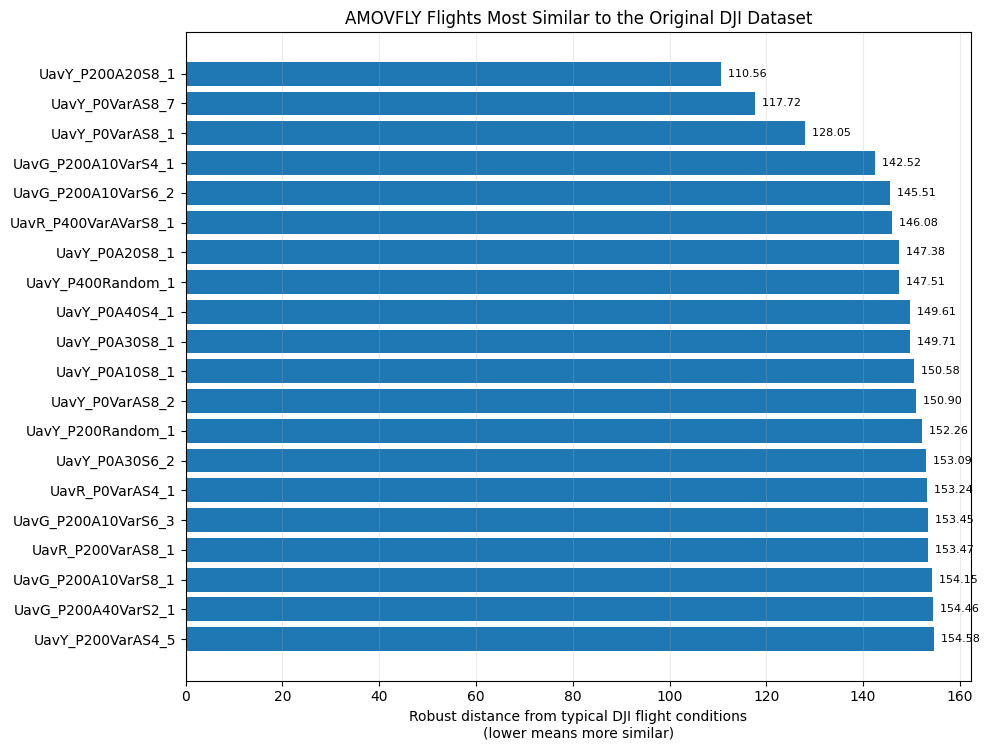

Saved ranking: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly\amovfly_flights_ranked_by_DJI_similarity.csv
Saved DJI summaries: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly\DJI_flight_condition_summary.csv
Saved AMOVFLY summaries: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly\AMOVFLY_flight_condition_summary.csv


In [9]:
# Rank AMOVFLY flights by similarity to the original DJI flight conditions.
#
# This cell compares flight-level distributions rather than raw coordinates.
# It handles DJI longitude/latitude and AMOVFLY local-meter coordinates.
#
# Required:
#   DJI_DATA_PATH      -> original standardized DJI CSV
#   AMOVFLY_DATA_PATH  -> combined standardized AMOVFLY CSV
#
# Optional:
#   EXTERNAL_PREDICTIONS_PATH -> Extra Trees predictions on AMOVFLY

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ============================================================
# PATHS — edit these if your notebook uses different variables
# ============================================================
DJI_DATA_PATH = (
    PROJECT_ROOT / "data" / "DJI_primary_standardized.csv"
    if "PROJECT_ROOT" in globals()
    else Path("data/DJI_primary_standardized.csv")
)

AMOVFLY_DATA_PATH = (
    COMBINED_EXTERNAL_PATH
    if "COMBINED_EXTERNAL_PATH" in globals()
    else Path("data/AMOVFLY_combined_standardized.csv")
)

EXTERNAL_PREDICTIONS_PATH = (
    PROJECT_ROOT / "results" / "external_amovfly"
    / "extra_trees" / "test_predictions.csv"
    if "PROJECT_ROOT" in globals()
    else Path(
        "results/external_amovfly/extra_trees/test_predictions.csv"
    )
)

DIRECTION_THRESHOLD = 1.0
TOP_N = 20
SAVE_OUTPUTS = True

# Similarity features are grouped so you can inspect *why* a flight matches.
WIND_FEATURES = [
    "wind_mean",
    "wind_std",
    "wind_p50",
    "wind_p90",
    "wind_gt1_fraction",
]

ATTITUDE_FEATURES = [
    "abs_roll_p50",
    "abs_roll_p90",
    "abs_pitch_p50",
    "abs_pitch_p90",
]

MOTION_FEATURES = [
    "duration_s",
    "altitude_range_m",
    "altitude_std_m",
    "horizontal_speed_p50_mps",
    "horizontal_speed_p90_mps",
    "abs_vertical_speed_p90_mps",
    "abs_yaw_rate_p90_rad_s",
]

SIMILARITY_FEATURES = (
    WIND_FEATURES
    + ATTITUDE_FEATURES
    + MOTION_FEATURES
)


def _numeric(frame: pd.DataFrame, column: str) -> pd.Series:
    if column not in frame.columns:
        return pd.Series(np.nan, index=frame.index, dtype=float)
    return pd.to_numeric(frame[column], errors="coerce")


def _looks_geographic(
    frame: pd.DataFrame,
    x: np.ndarray,
    y: np.ndarray,
) -> bool:
    if "Coordinate_frame" in frame.columns:
        labels = (
            frame["Coordinate_frame"]
            .astype("string")
            .str.lower()
            .dropna()
        )
        if labels.str.contains("geographic|lon_lat").any():
            return True

    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() < 2:
        return False

    xf = x[finite]
    yf = y[finite]
    return bool(
        np.mean(np.abs(xf) <= 180) > 0.99
        and np.mean(np.abs(yf) <= 90) > 0.99
        and np.nanmedian(np.abs(xf)) > 20
        and np.nanmedian(np.abs(yf)) > 10
    )


def _local_position_m(
    flight: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert one flight to local east/north/up coordinates in meters.

    Geographic X/Y are treated as longitude/latitude. Cartesian X/Y are
    centered without changing their units.
    """
    x = _numeric(flight, "X").to_numpy(dtype=float)
    y = _numeric(flight, "Y").to_numpy(dtype=float)
    z = _numeric(flight, "Z").to_numpy(dtype=float)

    valid_xy = np.isfinite(x) & np.isfinite(y)
    if not valid_xy.any():
        return (
            np.full(len(flight), np.nan),
            np.full(len(flight), np.nan),
            z,
        )

    first = int(np.flatnonzero(valid_xy)[0])
    x0 = float(x[first])
    y0 = float(y[first])

    if _looks_geographic(flight, x, y):
        earth_radius_m = 6_371_000.0
        lon = np.deg2rad(x)
        lat = np.deg2rad(y)
        lon0 = np.deg2rad(x0)
        lat0 = np.deg2rad(y0)

        east = earth_radius_m * np.cos(lat0) * (lon - lon0)
        north = earth_radius_m * (lat - lat0)
    else:
        east = x - x0
        north = y - y0

    valid_z = np.isfinite(z)
    if valid_z.any():
        z0 = float(z[np.flatnonzero(valid_z)[0]])
        up = z - z0
    else:
        up = z

    return east, north, up


def _time_seconds(flight: pd.DataFrame) -> np.ndarray:
    elapsed = _numeric(flight, "Elapsed_s").to_numpy(dtype=float)
    if np.isfinite(elapsed).sum() >= 2:
        return elapsed

    if "Timestamp" in flight.columns:
        timestamp = pd.to_datetime(
            flight["Timestamp"],
            errors="coerce",
        )
        if timestamp.notna().sum() >= 2:
            return (
                timestamp - timestamp.min()
            ).dt.total_seconds().to_numpy(dtype=float)

    return np.arange(len(flight), dtype=float)


def _safe_quantile(values: np.ndarray, q: float) -> float:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(np.quantile(values, q))


def _circular_difference_radians(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    return np.arctan2(
        np.sin(np.diff(values)),
        np.cos(np.diff(values)),
    )


def summarize_flight(
    flight: pd.DataFrame,
    flight_id: str,
    dataset: str,
) -> dict[str, float | str | int]:
    flight = flight.copy()

    order = np.argsort(
        np.nan_to_num(
            _time_seconds(flight),
            nan=np.inf,
        ),
        kind="stable",
    )
    flight = flight.iloc[order].reset_index(drop=True)

    time_s = _time_seconds(flight)
    east, north, up = _local_position_m(flight)

    wind = _numeric(flight, "Wind_speed").to_numpy(dtype=float)
    roll = _numeric(flight, "Roll").to_numpy(dtype=float)
    pitch = _numeric(flight, "Pitch").to_numpy(dtype=float)
    yaw = _numeric(flight, "Yaw").to_numpy(dtype=float)

    dt = np.diff(time_s)
    dx = np.diff(east)
    dy = np.diff(north)
    dz = np.diff(up)

    valid_dt = np.isfinite(dt) & (dt > 1e-6)

    horizontal_speed = np.full(len(dt), np.nan)
    vertical_speed = np.full(len(dt), np.nan)
    yaw_rate = np.full(len(dt), np.nan)

    horizontal_speed[valid_dt] = (
        np.sqrt(dx[valid_dt] ** 2 + dy[valid_dt] ** 2)
        / dt[valid_dt]
    )
    vertical_speed[valid_dt] = dz[valid_dt] / dt[valid_dt]

    if len(yaw) >= 2:
        yaw_delta = _circular_difference_radians(yaw)
        yaw_rate[valid_dt] = yaw_delta[valid_dt] / dt[valid_dt]

    finite_time = time_s[np.isfinite(time_s)]
    duration_s = (
        float(finite_time.max() - finite_time.min())
        if finite_time.size >= 2
        else np.nan
    )

    finite_up = up[np.isfinite(up)]
    altitude_range = (
        float(finite_up.max() - finite_up.min())
        if finite_up.size
        else np.nan
    )

    finite_wind = wind[np.isfinite(wind)]

    return {
        "dataset": dataset,
        "flight_id": str(flight_id),
        "n_rows": int(len(flight)),
        "duration_s": duration_s,

        "wind_mean": (
            float(finite_wind.mean())
            if finite_wind.size else np.nan
        ),
        "wind_std": (
            float(finite_wind.std(ddof=1))
            if finite_wind.size > 1 else np.nan
        ),
        "wind_p50": _safe_quantile(wind, 0.50),
        "wind_p90": _safe_quantile(wind, 0.90),
        "wind_gt1_fraction": (
            float(np.mean(finite_wind > DIRECTION_THRESHOLD))
            if finite_wind.size else np.nan
        ),

        "abs_roll_p50": _safe_quantile(np.abs(roll), 0.50),
        "abs_roll_p90": _safe_quantile(np.abs(roll), 0.90),
        "abs_pitch_p50": _safe_quantile(np.abs(pitch), 0.50),
        "abs_pitch_p90": _safe_quantile(np.abs(pitch), 0.90),

        "altitude_range_m": altitude_range,
        "altitude_std_m": (
            float(np.nanstd(finite_up, ddof=1))
            if finite_up.size > 1 else np.nan
        ),
        "horizontal_speed_p50_mps": _safe_quantile(
            horizontal_speed, 0.50
        ),
        "horizontal_speed_p90_mps": _safe_quantile(
            horizontal_speed, 0.90
        ),
        "abs_vertical_speed_p90_mps": _safe_quantile(
            np.abs(vertical_speed), 0.90
        ),
        "abs_yaw_rate_p90_rad_s": _safe_quantile(
            np.abs(yaw_rate), 0.90
        ),
    }


def summarize_dataset(
    frame: pd.DataFrame,
    dataset_name: str,
) -> pd.DataFrame:
    if "Flight_ID" not in frame.columns:
        raise KeyError(
            f"{dataset_name} data has no Flight_ID column."
        )

    rows = []
    for flight_id, flight in frame.groupby(
        "Flight_ID",
        sort=False,
        observed=True,
        dropna=False,
    ):
        rows.append(
            summarize_flight(
                flight,
                str(flight_id),
                dataset_name,
            )
        )
    return pd.DataFrame(rows)


def robust_scale_from_dji(
    dji_summary: pd.DataFrame,
    features: list[str],
) -> tuple[pd.Series, pd.Series]:
    center = dji_summary[features].median(axis=0)

    q25 = dji_summary[features].quantile(0.25)
    q75 = dji_summary[features].quantile(0.75)
    iqr_scale = (q75 - q25) / 1.349

    mad = (
        dji_summary[features]
        .sub(center)
        .abs()
        .median(axis=0)
        * 1.4826
    )

    fallback_std = dji_summary[features].std(axis=0)
    scale = (
        iqr_scale
        .where(iqr_scale > 1e-12)
        .fillna(mad)
        .where(lambda value: value > 1e-12)
        .fillna(fallback_std)
        .where(lambda value: value > 1e-12)
        .fillna(1.0)
    )
    return center, scale


def standardized_matrix(
    frame: pd.DataFrame,
    features: list[str],
    center: pd.Series,
    scale: pd.Series,
) -> np.ndarray:
    matrix = (
        frame[features]
        .sub(center, axis="columns")
        .div(scale, axis="columns")
        .to_numpy(dtype=float)
    )
    return matrix


def row_rms(values: np.ndarray) -> np.ndarray:
    finite = np.isfinite(values)
    count = finite.sum(axis=1)
    squared_sum = np.nansum(values ** 2, axis=1)
    return np.sqrt(
        np.divide(
            squared_sum,
            count,
            out=np.full(len(values), np.nan),
            where=count > 0,
        )
    )


# ============================================================
# Load and summarize
# ============================================================
DJI_DATA_PATH = Path(DJI_DATA_PATH)
AMOVFLY_DATA_PATH = Path(AMOVFLY_DATA_PATH)
EXTERNAL_PREDICTIONS_PATH = Path(EXTERNAL_PREDICTIONS_PATH)

if not DJI_DATA_PATH.exists():
    raise FileNotFoundError(
        f"DJI data not found: {DJI_DATA_PATH.resolve()}"
    )
if not AMOVFLY_DATA_PATH.exists():
    raise FileNotFoundError(
        f"AMOVFLY data not found: {AMOVFLY_DATA_PATH.resolve()}"
    )

dji_raw = pd.read_csv(DJI_DATA_PATH, low_memory=False)
amovfly_raw = pd.read_csv(AMOVFLY_DATA_PATH, low_memory=False)

dji_flights = summarize_dataset(dji_raw, "DJI")
amovfly_flights = summarize_dataset(amovfly_raw, "AMOVFLY")

usable_features = [
    feature
    for feature in SIMILARITY_FEATURES
    if (
        feature in dji_flights.columns
        and feature in amovfly_flights.columns
        and dji_flights[feature].notna().sum() >= 3
        and amovfly_flights[feature].notna().sum() >= 1
    )
]

if len(usable_features) < 5:
    raise RuntimeError(
        "Too few comparable features were available. "
        f"Usable features: {usable_features}"
    )

center, scale = robust_scale_from_dji(
    dji_flights,
    usable_features,
)

dji_z = standardized_matrix(
    dji_flights,
    usable_features,
    center,
    scale,
)
amovfly_z = standardized_matrix(
    amovfly_flights,
    usable_features,
    center,
    scale,
)

# Distance from the typical DJI flight.
amovfly_flights["overall_similarity_distance"] = row_rms(
    amovfly_z
)

for group_name, group_features in {
    "wind": WIND_FEATURES,
    "attitude": ATTITUDE_FEATURES,
    "motion": MOTION_FEATURES,
}.items():
    available = [
        feature
        for feature in group_features
        if feature in usable_features
    ]
    indices = [
        usable_features.index(feature)
        for feature in available
    ]
    amovfly_flights[
        f"{group_name}_distance"
    ] = row_rms(amovfly_z[:, indices])

# Find the nearest individual DJI flight.
nearest_ids = []
nearest_distances = []

for amov_row in amovfly_z:
    difference = dji_z - amov_row[None, :]
    pairwise = row_rms(difference)
    nearest_index = int(np.nanargmin(pairwise))
    nearest_ids.append(
        str(dji_flights.iloc[nearest_index]["flight_id"])
    )
    nearest_distances.append(
        float(pairwise[nearest_index])
    )

amovfly_flights["nearest_DJI_flight"] = nearest_ids
amovfly_flights[
    "nearest_DJI_flight_distance"
] = nearest_distances

# Fraction of metrics inside the DJI 5th–95th percentile range.
dji_low = dji_flights[usable_features].quantile(0.05)
dji_high = dji_flights[usable_features].quantile(0.95)

inside = (
    amovfly_flights[usable_features]
    .ge(dji_low, axis="columns")
    & amovfly_flights[usable_features]
    .le(dji_high, axis="columns")
)
available = amovfly_flights[usable_features].notna()

amovfly_flights["DJI_range_overlap_fraction"] = (
    (inside & available).sum(axis=1)
    / available.sum(axis=1).replace(0, np.nan)
)

# Optional: merge Extra Trees external performance by flight.
if EXTERNAL_PREDICTIONS_PATH.exists():
    predictions = pd.read_csv(
        EXTERNAL_PREDICTIONS_PATH,
        low_memory=False,
    )

    required_prediction_columns = {
        "Flight_ID",
        "Wind_speed",
        "Wind_angle",
        "Predicted_wind_speed",
        "Predicted_wind_angle",
    }

    if required_prediction_columns.issubset(predictions.columns):
        true_speed = pd.to_numeric(
            predictions["Wind_speed"],
            errors="coerce",
        )
        predicted_speed = pd.to_numeric(
            predictions["Predicted_wind_speed"],
            errors="coerce",
        )
        true_angle = pd.to_numeric(
            predictions["Wind_angle"],
            errors="coerce",
        )
        predicted_angle = pd.to_numeric(
            predictions["Predicted_wind_angle"],
            errors="coerce",
        )

        predictions["_abs_speed_error"] = (
            predicted_speed - true_speed
        ).abs()
        predictions["_abs_direction_error"] = np.abs(
            (
                predicted_angle - true_angle + 180.0
            ) % 360.0 - 180.0
        )

        speed_metrics = (
            predictions.groupby(
                "Flight_ID",
                observed=True,
            )
            .agg(
                external_rows=("Flight_ID", "size"),
                external_speed_mae_mps=(
                    "_abs_speed_error",
                    "mean",
                ),
            )
        )

        direction_metrics = (
            predictions.loc[
                true_speed > DIRECTION_THRESHOLD
            ]
            .groupby(
                "Flight_ID",
                observed=True,
            )
            .agg(
                external_direction_rows=(
                    "Flight_ID",
                    "size",
                ),
                external_direction_mae_deg=(
                    "_abs_direction_error",
                    "mean",
                ),
            )
        )

        performance = (
            speed_metrics
            .join(direction_metrics, how="left")
            .reset_index()
        )
        performance["flight_id"] = (
            performance["Flight_ID"].astype(str)
        )
        performance = performance.drop(
            columns=["Flight_ID"]
        )

        amovfly_flights = amovfly_flights.merge(
            performance,
            on="flight_id",
            how="left",
        )

# Final ranking.
ranking = (
    amovfly_flights
    .sort_values(
        [
            "overall_similarity_distance",
            "nearest_DJI_flight_distance",
            "flight_id",
        ],
        ascending=[True, True, True],
    )
    .reset_index(drop=True)
)
ranking.insert(0, "similarity_rank", np.arange(1, len(ranking) + 1))

print(f"DJI flights summarized:      {len(dji_flights):,}")
print(f"AMOVFLY flights summarized:  {len(amovfly_flights):,}")
print(f"Similarity features used:    {len(usable_features)}")
print("Features:", usable_features)

columns_to_show = [
    "similarity_rank",
    "flight_id",
    "overall_similarity_distance",
    "wind_distance",
    "attitude_distance",
    "motion_distance",
    "DJI_range_overlap_fraction",
    "nearest_DJI_flight",
    "nearest_DJI_flight_distance",
    "wind_mean",
    "wind_p90",
    "duration_s",
    "altitude_range_m",
    "abs_roll_p90",
    "abs_pitch_p90",
]

for optional_column in [
    "external_speed_mae_mps",
    "external_direction_mae_deg",
]:
    if optional_column in ranking.columns:
        columns_to_show.append(optional_column)

display(
    ranking[columns_to_show]
    .head(TOP_N)
    .style.format({
        "overall_similarity_distance": "{:.3f}",
        "wind_distance": "{:.3f}",
        "attitude_distance": "{:.3f}",
        "motion_distance": "{:.3f}",
        "DJI_range_overlap_fraction": "{:.1%}",
        "nearest_DJI_flight_distance": "{:.3f}",
        "wind_mean": "{:.3f}",
        "wind_p90": "{:.3f}",
        "duration_s": "{:.1f}",
        "altitude_range_m": "{:.2f}",
        "abs_roll_p90": "{:.3f}",
        "abs_pitch_p90": "{:.3f}",
        "external_speed_mae_mps": "{:.3f}",
        "external_direction_mae_deg": "{:.1f}",
    })
)

# ============================================================
# Plot the most similar AMOVFLY flights
# ============================================================
plot_data = ranking.head(TOP_N).sort_values(
    "overall_similarity_distance",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, max(6, 0.38 * len(plot_data))))

ax.barh(
    plot_data["flight_id"],
    plot_data["overall_similarity_distance"],
)
ax.invert_yaxis()
ax.set_xlabel(
    "Robust distance from typical DJI flight conditions\n"
    "(lower means more similar)"
)
ax.set_title(
    "AMOVFLY Flights Most Similar to the Original DJI Dataset"
)
ax.grid(axis="x", alpha=0.25)

for index, value in enumerate(
    plot_data["overall_similarity_distance"]
):
    ax.text(
        value,
        index,
        f"  {value:.2f}",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

# ============================================================
# Save
# ============================================================
if SAVE_OUTPUTS:
    output_dir = (
        PROJECT_ROOT / "results" / "external_amovfly"
        if "PROJECT_ROOT" in globals()
        else Path("results/external_amovfly")
    )
    output_dir.mkdir(parents=True, exist_ok=True)

    ranking_path = (
        output_dir
        / "amovfly_flights_ranked_by_DJI_similarity.csv"
    )
    dji_summary_path = (
        output_dir
        / "DJI_flight_condition_summary.csv"
    )
    amovfly_summary_path = (
        output_dir
        / "AMOVFLY_flight_condition_summary.csv"
    )

    ranking.to_csv(ranking_path, index=False)
    dji_flights.to_csv(dji_summary_path, index=False)
    amovfly_flights.to_csv(amovfly_summary_path, index=False)

    print(f"Saved ranking: {ranking_path}")
    print(f"Saved DJI summaries: {dji_summary_path}")
    print(f"Saved AMOVFLY summaries: {amovfly_summary_path}")

## 5. Final selections

In [10]:
display(selections)
display(finalists[
    [
        "display_name",
        "roles",
        "common_speed_mae_mps",
        "common_direction_mae_deg_above_threshold",
        "balanced_hybrid_score",
    ]
])

speed_winner = selections.loc[selections["category"] == "best_common_speed", "model"].iloc[0]
direction_winner = selections.loc[selections["category"] == "best_direction_above_threshold", "model"].iloc[0]
balanced_winner = selections.loc[selections["category"] == "best_balanced_hybrid", "model"].iloc[0]

print(f"Best common speed model:         {models[speed_winner].display_name}")
print(f"Best direction model >1 m/s:    {models[direction_winner].display_name}")
print(f"Strongest balanced model:       {models[balanced_winner].display_name}")

,category,model,display_name,metric,value,units,definition
0,best_common_speed,extra_trees,Extra Trees,common_speed_mae_mps,1.3964,m/s,Lowest speed MAE on the exact common eligible ...
1,best_direction_above_threshold,extra_trees,Extra Trees,common_direction_mae_deg_above_threshold,86.3875,degrees,Lowest circular direction MAE on common rows w...
2,best_balanced_hybrid,extra_trees,Extra Trees,balanced_hybrid_score,1.0000,relative score; lower is better,Equal-weight geometric mean of speed-MAE regre...


,display_name,roles,common_speed_mae_mps,common_direction_mae_deg_above_threshold,balanced_hybrid_score
0,Extra Trees,best_common_speed;best_direction_above_thresho...,1.3964,86.3875,1.0000


Best common speed model:         Extra Trees
Best direction model >1 m/s:    Extra Trees
Strongest balanced model:       Extra Trees


## 6. Speed and direction leaderboard charts

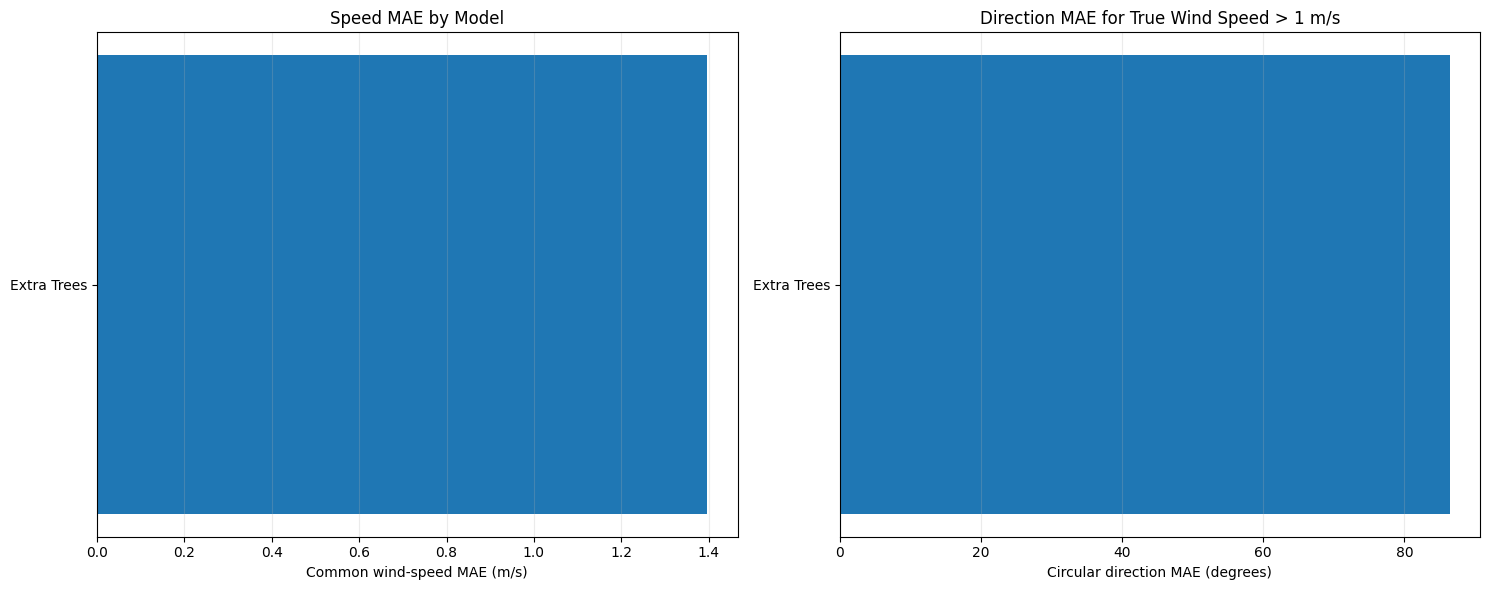

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

speed_order = comparison.sort_values("common_speed_mae_mps", ascending=True)
axes[0].barh(speed_order["display_name"], speed_order["common_speed_mae_mps"])
axes[0].invert_yaxis()
axes[0].set_xlabel("Common wind-speed MAE (m/s)")
axes[0].set_title("Speed MAE by Model")
axes[0].grid(axis="x", alpha=0.25)

direction_metric = "common_direction_mae_deg_above_threshold"
direction_order = comparison.sort_values(direction_metric, ascending=True)
axes[1].barh(direction_order["display_name"], direction_order[direction_metric])
axes[1].invert_yaxis()
axes[1].set_xlabel("Circular direction MAE (degrees)")
axes[1].set_title(f"Direction MAE for True Wind Speed > {DIRECTION_MIN_SPEED:g} m/s")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## 7. Interactive model selector

In [12]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    model_options = [(models[name].display_name, name) for name in sorted(models)]
    model_dropdown = widgets.Dropdown(
        options=model_options,
        value=balanced_winner,
        description="Model:",
        layout=widgets.Layout(width="420px"),
    )
    display(model_dropdown)
    print("Use model_dropdown.value in the cells below.")
except ImportError:
    model_dropdown = None
    print("ipywidgets is not installed. Set SELECTED_MODEL manually in the configuration cell.")

Dropdown(description='Model:', layout=Layout(width='420px'), options=(('Extra Trees', 'extra_trees'),), value=…

Use model_dropdown.value in the cells below.


## 8. Predicted versus true wind speed

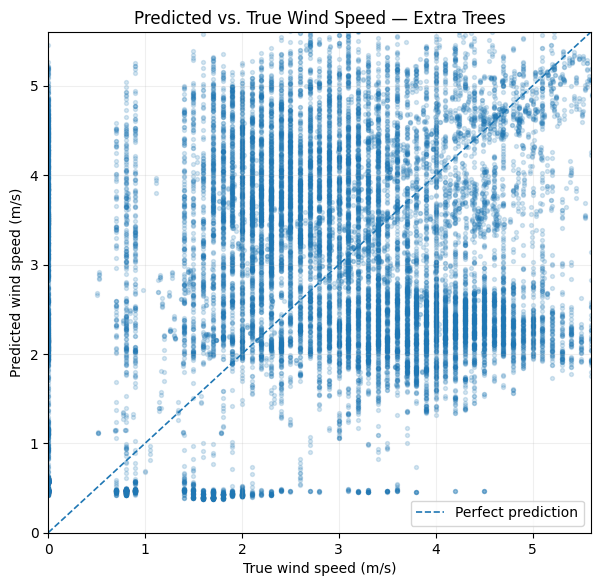

In [13]:
def current_model(default: str = balanced_winner) -> str:
    if model_dropdown is not None:
        return model_dropdown.value
    return SELECTED_MODEL or default

model_name = current_model(speed_winner)
frame = frames[model_name].dropna(subset=["true_speed", "pred_speed"]).copy()

max_points = 20_000
plot_frame = frame if len(frame) <= max_points else frame.sample(max_points, random_state=RANDOM_SEED)
lower = float(min(plot_frame["true_speed"].min(), plot_frame["pred_speed"].min()))
upper = float(max(plot_frame["true_speed"].quantile(0.995), plot_frame["pred_speed"].quantile(0.995)))

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(plot_frame["true_speed"], plot_frame["pred_speed"], s=8, alpha=0.18, rasterized=True)
ax.plot([lower, upper], [lower, upper], linestyle="--", linewidth=1.2, label="Perfect prediction")
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("True wind speed (m/s)")
ax.set_ylabel("Predicted wind speed (m/s)")
ax.set_title(f"Predicted vs. True Wind Speed — {models[model_name].display_name}")
ax.grid(alpha=0.2)
ax.legend()
plt.show()

## 9. Direction-error distribution across all models

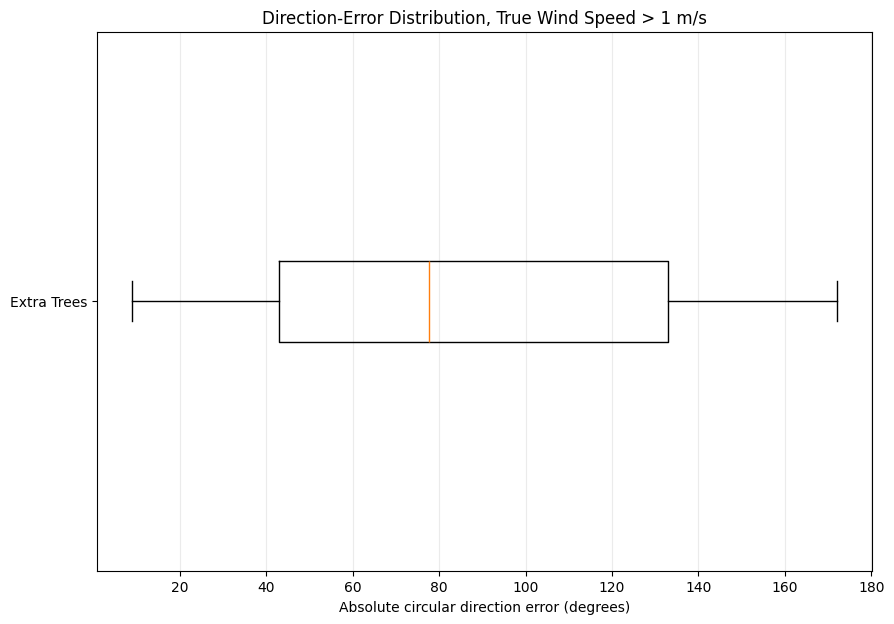

In [14]:
order = comparison.sort_values(
    "common_direction_mae_deg_above_threshold"
)["model"].tolist()

arrays = [
    frames[model].loc[
        frames[model]["true_speed"] > DIRECTION_MIN_SPEED,
        "abs_direction_error",
    ].dropna().to_numpy()
    for model in order
]
labels = [models[model].display_name for model in order]

fig, ax = plt.subplots(figsize=(10, 7))
ax.boxplot(arrays, vert=False, tick_labels=labels, whis=(5, 95), showfliers=False)
ax.invert_yaxis()
ax.set_xlabel("Absolute circular direction error (degrees)")
ax.set_title(f"Direction-Error Distribution, True Wind Speed > {DIRECTION_MIN_SPEED:g} m/s")
ax.grid(axis="x", alpha=0.25)
plt.show()

## 10. Direction MAE by wind-speed bin

,model,display_name,speed_bin,direction_mae_deg,n
0,extra_trees,Extra Trees,0–0.5,76.9141,2718
1,extra_trees,Extra Trees,0.5–1,81.7852,1140
2,extra_trees,Extra Trees,1–2,86.9140,3183
3,extra_trees,Extra Trees,2–4,80.9104,15593
4,extra_trees,Extra Trees,4–6,98.9182,6600


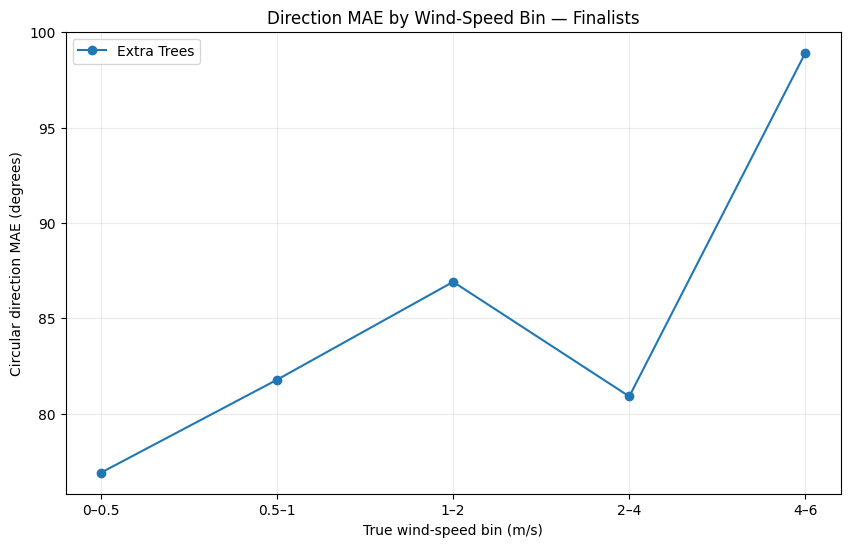

In [15]:
speed_edges = [0.0, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 12.0, np.inf]
speed_labels = ["0–0.5", "0.5–1", "1–2", "2–4", "4–6", "6–8", "8–12", "12+"]

rows = []
for model_name, model_data in frames.items():
    temp = model_data.copy()
    temp["speed_bin"] = pd.cut(
        temp["true_speed"],
        bins=speed_edges,
        labels=speed_labels,
        right=False,
        include_lowest=True,
    )
    grouped = temp.groupby("speed_bin", observed=False)["abs_direction_error"].agg(["mean", "count"])
    for speed_bin, values in grouped.iterrows():
        rows.append({
            "model": model_name,
            "display_name": models[model_name].display_name,
            "speed_bin": speed_bin,
            "direction_mae_deg": values["mean"],
            "n": int(values["count"]),
        })

direction_by_bin = pd.DataFrame(rows)
display(direction_by_bin.head())

fig, ax = plt.subplots(figsize=(10, 6))
for model_name in finalists["model"]:
    subset = (
        direction_by_bin[direction_by_bin["model"] == model_name]
        .set_index("speed_bin")
        .reindex(speed_labels)
    )
    y = subset["direction_mae_deg"].where(subset["n"] >= 30)
    ax.plot(speed_labels, y, marker="o", linewidth=1.5, label=models[model_name].display_name)

ax.set_xlabel("True wind-speed bin (m/s)")
ax.set_ylabel("Circular direction MAE (degrees)")
ax.set_title("Direction MAE by Wind-Speed Bin — Finalists")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## 11. Pairwise comparison of any two models

In [16]:
def pairwise_summary(model_a: str, model_b: str) -> pd.DataFrame:
    a = frames[model_a][["row_key", "abs_speed_error", "abs_direction_error", "true_speed"]].copy()
    b = frames[model_b][["row_key", "abs_speed_error", "abs_direction_error"]].copy()
    merged = a.merge(b, on="row_key", suffixes=("_a", "_b"), validate="one_to_one")

    direction_mask = merged["true_speed"] > DIRECTION_MIN_SPEED
    return pd.DataFrame({
        "metric": [
            "Speed MAE",
            f"Direction MAE > {DIRECTION_MIN_SPEED:g} m/s",
            "Rows where A has lower speed error",
            "Rows where A has lower direction error",
        ],
        models[model_a].display_name: [
            merged["abs_speed_error_a"].mean(),
            merged.loc[direction_mask, "abs_direction_error_a"].mean(),
            (merged["abs_speed_error_a"] < merged["abs_speed_error_b"]).mean(),
            (
                merged.loc[direction_mask, "abs_direction_error_a"]
                < merged.loc[direction_mask, "abs_direction_error_b"]
            ).mean(),
        ],
        models[model_b].display_name: [
            merged["abs_speed_error_b"].mean(),
            merged.loc[direction_mask, "abs_direction_error_b"].mean(),
            (merged["abs_speed_error_b"] < merged["abs_speed_error_a"]).mean(),
            (
                merged.loc[direction_mask, "abs_direction_error_b"]
                < merged.loc[direction_mask, "abs_direction_error_a"]
            ).mean(),
        ],
    })

MODEL_A = speed_winner
MODEL_B = balanced_winner if balanced_winner != MODEL_A else direction_winner
pairwise_summary(MODEL_A, MODEL_B)

,metric,Extra Trees
0,Speed MAE,1.3964
1,Direction MAE > 1 m/s,86.3875
2,Rows where A has lower speed error,0.0000
3,Rows where A has lower direction error,0.0000


## 12. Per-flight finalist comparison

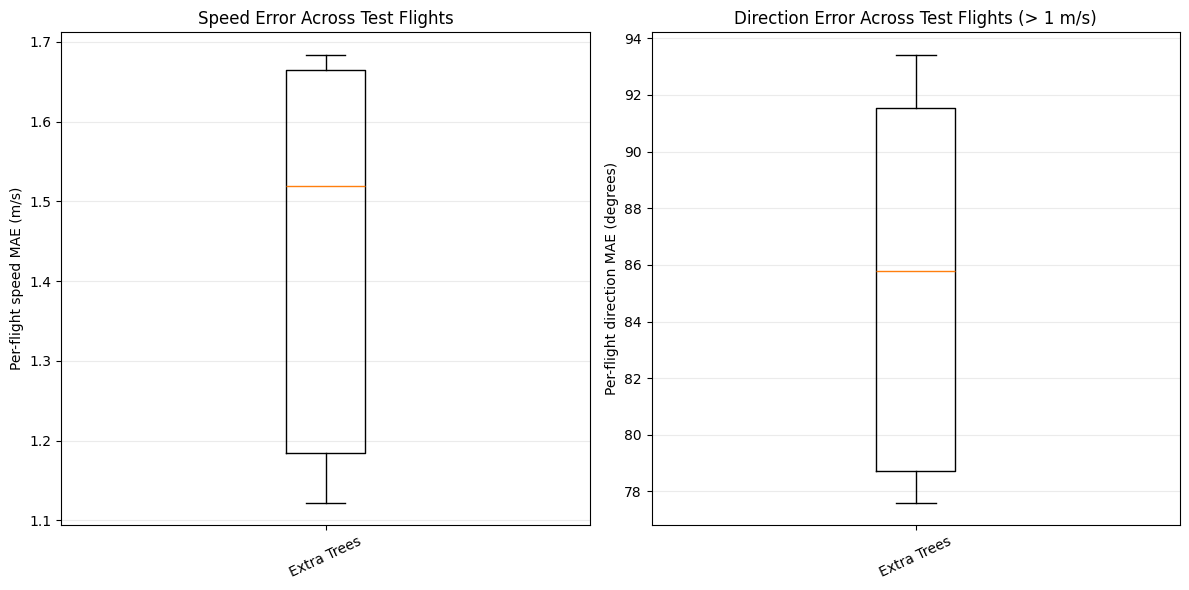

In [17]:
def per_flight_metrics(frame: pd.DataFrame) -> pd.DataFrame:
    speed = frame.groupby("group_id").agg(
        n=("row_key", "size"),
        speed_mae_mps=("abs_speed_error", "mean"),
    )
    direction = (
        frame[frame["true_speed"] > DIRECTION_MIN_SPEED]
        .groupby("group_id")
        .agg(
            direction_n=("row_key", "size"),
            direction_mae_deg=("abs_direction_error", "mean"),
        )
    )
    return speed.join(direction, how="left").reset_index()

flight_tables = {
    model_name: per_flight_metrics(frames[model_name])
    for model_name in finalists["model"]
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
labels = [models[name].display_name for name in finalists["model"]]

axes[0].boxplot(
    [flight_tables[name]["speed_mae_mps"].dropna().to_numpy() for name in finalists["model"]],
    tick_labels=labels,
    whis=(5, 95),
    showfliers=False,
)
axes[0].set_ylabel("Per-flight speed MAE (m/s)")
axes[0].set_title("Speed Error Across Test Flights")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.25)

axes[1].boxplot(
    [flight_tables[name]["direction_mae_deg"].dropna().to_numpy() for name in finalists["model"]],
    tick_labels=labels,
    whis=(5, 95),
    showfliers=False,
)
axes[1].set_ylabel("Per-flight direction MAE (degrees)")
axes[1].set_title(f"Direction Error Across Test Flights (> {DIRECTION_MIN_SPEED:g} m/s)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 13. Find flights where models differ most

In [18]:
model_a = speed_winner
model_b = balanced_winner if balanced_winner != model_a else direction_winner

a = flight_tables[model_a][["group_id", "n", "speed_mae_mps", "direction_mae_deg"]]
b = flight_tables[model_b][["group_id", "speed_mae_mps", "direction_mae_deg"]]
flight_difference = a.merge(b, on="group_id", suffixes=("_a", "_b"), validate="one_to_one")
flight_difference["speed_mae_difference_a_minus_b"] = (
    flight_difference["speed_mae_mps_a"] - flight_difference["speed_mae_mps_b"]
)
flight_difference["direction_mae_difference_a_minus_b"] = (
    flight_difference["direction_mae_deg_a"] - flight_difference["direction_mae_deg_b"]
)

print(f"A = {models[model_a].display_name}")
print(f"B = {models[model_b].display_name}")
display(
    flight_difference.sort_values(
        "speed_mae_difference_a_minus_b",
        key=lambda series: series.abs(),
        ascending=False,
    ).head(15)
)

A = Extra Trees
B = Extra Trees


,group_id,n,speed_mae_mps_a,direction_mae_deg_a,speed_mae_mps_b,direction_mae_deg_b,speed_mae_difference_a_minus_b,direction_mae_difference_a_minus_b
0,AMOVFLY::UavG_P200A10VarS2_1,3353,1.5315,92.1223,1.5315,92.1223,0.0000,0.0000
1,AMOVFLY::UavG_P200A10VarS2_2,2859,1.5073,93.4167,1.5073,93.4167,0.0000,0.0000
2,AMOVFLY::UavG_P200A10VarS2_3,2818,1.6080,89.7393,1.6080,89.7393,0.0000,0.0000
3,AMOVFLY::UavG_P200A40VarS2_1,2573,1.1226,83.6821,1.1226,83.6821,0.0000,0.0000
4,AMOVFLY::UavG_P200A40VarS2_2,2664,1.1225,77.3331,1.1225,77.3331,0.0000,0.0000
5,AMOVFLY::UavG_P200A40VarS2_3,2593,1.3726,78.5631,1.3726,78.5631,0.0000,0.0000
6,AMOVFLY::UavR_P200A40VarS2_1,2797,1.7382,102.1434,1.7382,102.1434,0.0000,0.0000
7,AMOVFLY::UavR_P200A40VarS2_2,2805,1.6840,87.8524,1.6840,87.8524,0.0000,0.0000
8,AMOVFLY::UavY_P0A30S2_1,3415,0.6337,77.6113,0.6337,77.6113,0.0000,0.0000
9,AMOVFLY::UavY_P200A40VarS2_2,3377,1.6839,79.2642,1.6839,79.2642,0.0000,0.0000


## 14. Representative-flight time series

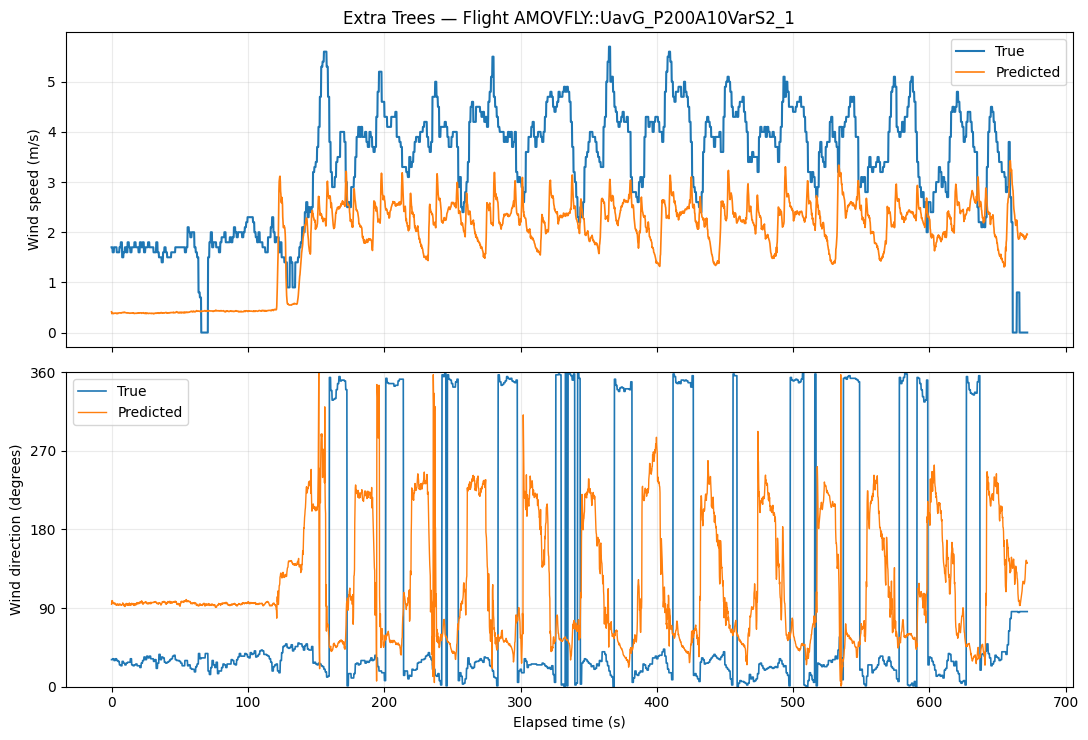

In [19]:
def choose_representative_flight(model_name: str, min_rows: int = 100) -> str:
    metrics = per_flight_metrics(frames[model_name])
    eligible = metrics[(metrics["n"] >= min_rows) & metrics["direction_mae_deg"].notna()].copy()
    if eligible.empty:
        eligible = metrics.dropna(subset=["direction_mae_deg"]).copy()

    speed_median = eligible["speed_mae_mps"].median()
    direction_median = eligible["direction_mae_deg"].median()
    eligible["distance_from_median"] = (
        (eligible["speed_mae_mps"] - speed_median).abs() / max(speed_median, 1e-9)
        + (eligible["direction_mae_deg"] - direction_median).abs() / max(direction_median, 1e-9)
    )
    return str(
        eligible.sort_values(["distance_from_median", "n"], ascending=[True, False])
        .iloc[0]["group_id"]
    )

model_name = current_model(balanced_winner)
group_id = SELECTED_FLIGHT or choose_representative_flight(model_name)
flight = frames[model_name][frames[model_name]["group_id"].astype(str) == str(group_id)].copy()
flight = flight.sort_values("sample_index")

elapsed = pd.to_numeric(flight["elapsed_s"], errors="coerce")
if elapsed.notna().sum() >= 2 and elapsed.nunique(dropna=True) >= 2:
    x = elapsed.to_numpy(dtype=float)
    x_label = "Elapsed time (s)"
else:
    x = pd.to_numeric(flight["sample_index"], errors="coerce").to_numpy(dtype=float)
    x_label = "Sample index"

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

axes[0].plot(x, flight["true_speed"], linewidth=1.5, label="True")
axes[0].plot(x, flight["pred_speed"], linewidth=1.2, label="Predicted")
axes[0].set_ylabel("Wind speed (m/s)")
axes[0].set_title(f"{models[model_name].display_name} — Flight {group_id}")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(x, flight["true_angle"], linewidth=1.2, label="True")
axes[1].plot(x, flight["pred_angle"], linewidth=1.0, label="Predicted")
axes[1].set_xlabel(x_label)
axes[1].set_ylabel("Wind direction (degrees)")
axes[1].set_ylim(0, 360)
axes[1].set_yticks([0, 90, 180, 270, 360])
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## 15. Direction confidence versus direction error

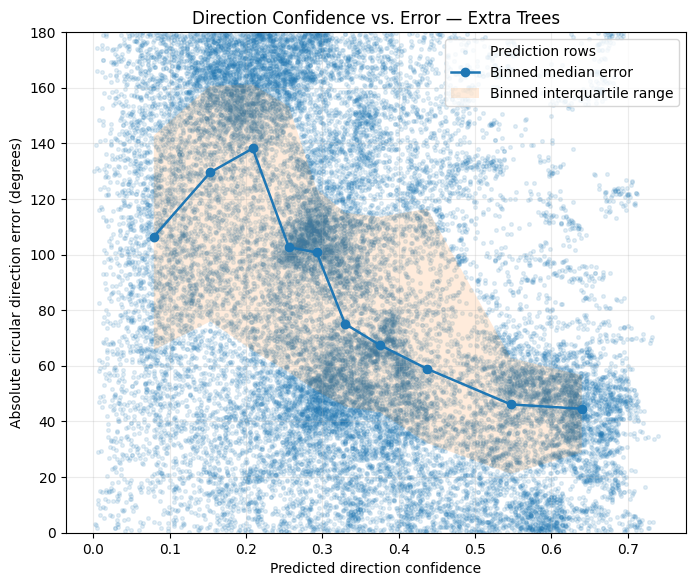

,confidence,median_error,q25_error,q75_error,n
0,0.0792,106.4530,65.6788,142.8872,2540
1,0.1531,129.5915,76.0054,160.7790,2539
2,0.2087,138.2019,65.5286,161.2126,2539
3,0.2561,102.7257,57.7072,153.3546,2539
4,0.2925,100.7807,51.0070,123.6288,2539
5,0.3297,75.1138,45.3736,115.1174,2539
6,0.3753,67.4790,43.2922,113.5967,2539
7,0.4375,58.9023,32.2171,116.5034,2539
8,0.5468,46.1437,21.1711,62.8564,2539
9,0.6398,44.5724,28.8434,56.6395,2539


In [20]:
model_name = current_model(balanced_winner)
confidence_frame = frames[model_name][
    (frames[model_name]["true_speed"] > DIRECTION_MIN_SPEED)
    & frames[model_name]["confidence"].notna()
    & frames[model_name]["abs_direction_error"].notna()
].copy()

if confidence_frame.empty:
    print(f"{models[model_name].display_name} has no finite direction-confidence values.")
else:
    max_points = 30_000
    plot_frame = (
        confidence_frame
        if len(confidence_frame) <= max_points
        else confidence_frame.sample(max_points, random_state=RANDOM_SEED)
    )

    quantile_edges = np.unique(
        confidence_frame["confidence"].quantile(np.linspace(0, 1, 11)).to_numpy()
    )
    if len(quantile_edges) >= 3:
        confidence_frame["confidence_bin"] = pd.cut(
            confidence_frame["confidence"],
            bins=quantile_edges,
            include_lowest=True,
            duplicates="drop",
        )
        confidence_bins = (
            confidence_frame.groupby("confidence_bin", observed=True)
            .agg(
                confidence=("confidence", "median"),
                median_error=("abs_direction_error", "median"),
                q25_error=("abs_direction_error", lambda x: x.quantile(0.25)),
                q75_error=("abs_direction_error", lambda x: x.quantile(0.75)),
                n=("abs_direction_error", "size"),
            )
            .reset_index(drop=True)
        )
    else:
        confidence_bins = pd.DataFrame()

    fig, ax = plt.subplots(figsize=(8, 6.5))
    ax.scatter(
        plot_frame["confidence"],
        plot_frame["abs_direction_error"],
        s=7,
        alpha=0.12,
        rasterized=True,
        label="Prediction rows",
    )
    if not confidence_bins.empty:
        ax.plot(
            confidence_bins["confidence"],
            confidence_bins["median_error"],
            marker="o",
            linewidth=1.8,
            label="Binned median error",
        )
        ax.fill_between(
            confidence_bins["confidence"].to_numpy(dtype=float),
            confidence_bins["q25_error"].to_numpy(dtype=float),
            confidence_bins["q75_error"].to_numpy(dtype=float),
            alpha=0.15,
            label="Binned interquartile range",
        )

    ax.set_xlabel("Predicted direction confidence")
    ax.set_ylabel("Absolute circular direction error (degrees)")
    ax.set_title(f"Direction Confidence vs. Error — {models[model_name].display_name}")
    ax.set_ylim(0, 180)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    display(confidence_bins)

In [26]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError(
        "This cell needs ipywidgets. In Anaconda Prompt run: "
        "conda install ipywidgets"
    ) from exc

if "models" not in globals() or "frames" not in globals():
    raise RuntimeError(
        "Run the notebook's setup, loading, and common-metric cells "
        "before this cell."
    )


# ============================================================
# Figure export settings
# ============================================================
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "external_amovfly_figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# These globals are updated whenever Update comparison is clicked.
CURRENT_SEQUENCE_FIG = None
CURRENT_SEQUENCE_SUMMARY = None
CURRENT_SEQUENCE_FLIGHT_ID = None
CURRENT_SEQUENCE_MODELS = None


def _safe_filename(value: str) -> str:
    """Convert a label into a filesystem-safe filename component."""
    value = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value))
    return value.strip("_") or "unnamed"


def _common_flights(
    selected_models: list[str],
) -> list[tuple[str, int]]:
    """Return flights shared by all selected models, ordered by row count."""
    if not selected_models:
        return []

    common = None

    for model_name in selected_models:
        counts = (
            frames[model_name]
            .assign(
                group_id=lambda frame: (
                    frame["group_id"].astype(str)
                )
            )
            .groupby("group_id")
            .size()
        )

        flight_ids = set(counts.index.astype(str))

        common = (
            flight_ids
            if common is None
            else common.intersection(flight_ids)
        )

    first_counts = (
        frames[selected_models[0]]
        .assign(
            group_id=lambda frame: (
                frame["group_id"].astype(str)
            )
        )
        .groupby("group_id")
        .size()
    )

    return sorted(
        [
            (
                flight_id,
                int(first_counts.get(flight_id, 0)),
            )
            for flight_id in common
        ],
        key=lambda item: (-item[1], item[0]),
    )


def _aligned_flight_frame(
    selected_models: list[str],
    flight_id: str,
) -> pd.DataFrame:
    """Align one flight across models by the common row key."""
    first = selected_models[0]

    base = frames[first].loc[
        frames[first]["group_id"].astype(str)
        == str(flight_id),
        [
            "row_key",
            "sample_index",
            "true_speed",
            "true_angle",
        ],
    ].copy()

    for model_name in selected_models:
        pred = frames[model_name].loc[
            frames[model_name]["group_id"].astype(str)
            == str(flight_id),
            [
                "row_key",
                "pred_speed",
                "pred_angle",
                "speed_error",
                "direction_error",
            ],
        ].copy()

        pred = pred.rename(
            columns={
                "pred_speed": (
                    f"pred_speed__{model_name}"
                ),
                "pred_angle": (
                    f"pred_angle__{model_name}"
                ),
                "speed_error": (
                    f"speed_error__{model_name}"
                ),
                "direction_error": (
                    f"direction_error__{model_name}"
                ),
            }
        )

        base = base.merge(
            pred,
            on="row_key",
            how="inner",
            validate="one_to_one",
        )

    return (
        base
        .sort_values(
            ["sample_index", "row_key"],
            kind="stable",
        )
        .reset_index(drop=True)
    )


def plot_model_sequence_comparison(
    selected_models: list[str],
    flight_id: str,
    max_points: int = 1500,
):
    """Compare observed wind with one or more models along one flight."""
    if not selected_models:
        raise ValueError("Select at least one model.")

    flight = _aligned_flight_frame(
        selected_models,
        flight_id,
    )

    if flight.empty:
        raise ValueError(
            f"No aligned rows found for flight {flight_id!r}."
        )

    if len(flight) > max_points:
        positions = np.unique(
            np.rint(
                np.linspace(
                    0,
                    len(flight) - 1,
                    max_points,
                )
            ).astype(int)
        )
        flight = flight.iloc[positions].copy()

    x = flight["sample_index"]

    fig = make_subplots(
        rows=4,
        cols=1,
        shared_xaxes=True,
        subplot_titles=(
            "Wind speed",
            "Wind direction-from",
            "Speed prediction error",
            "Circular direction error",
        ),
        vertical_spacing=0.065,
    )

    fig.add_trace(
        go.Scatter(
            x=x,
            y=flight["true_speed"],
            mode="lines",
            name="Observed speed",
            line={"width": 2.5},
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=x,
            y=flight["true_angle"],
            mode="lines",
            name="Observed direction",
            line={"width": 2.5},
        ),
        row=2,
        col=1,
    )

    summary_rows = []

    for model_name in selected_models:
        label = models[model_name].display_name

        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[
                    f"pred_speed__{model_name}"
                ],
                mode="lines",
                name=f"{label} speed",
                line={"dash": "dash"},
            ),
            row=1,
            col=1,
        )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[
                    f"pred_angle__{model_name}"
                ],
                mode="lines",
                name=f"{label} direction",
                line={"dash": "dash"},
            ),
            row=2,
            col=1,
        )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[
                    f"speed_error__{model_name}"
                ],
                mode="lines",
                name=f"{label} speed error",
            ),
            row=3,
            col=1,
        )

        fig.add_trace(
            go.Scatter(
                x=x,
                y=flight[
                    f"direction_error__{model_name}"
                ],
                mode="lines",
                name=f"{label} direction error",
            ),
            row=4,
            col=1,
        )

        direction_mask = (
            flight["true_speed"]
            > DIRECTION_MIN_SPEED
        )

        summary_rows.append(
            {
                "model": label,
                "flight_rows_plotted": len(flight),
                "flight_speed_mae_mps": (
                    flight[
                        f"speed_error__{model_name}"
                    ]
                    .abs()
                    .mean()
                ),
                (
                    "flight_direction_mae_deg_above_"
                    f"{DIRECTION_MIN_SPEED:g}_mps"
                ): (
                    flight.loc[
                        direction_mask,
                        f"direction_error__{model_name}",
                    ]
                    .abs()
                    .mean()
                ),
            }
        )

    fig.update_layout(
        title=(
            "Observed and predicted wind along flight "
            f"{flight_id}"
            f"<br><sup>{len(flight):,} aligned plotted rows; "
            f"{len(selected_models)} selected model(s)</sup>"
        ),
        template="plotly_white",
        width=1500,
        height=1200,
        hovermode="x unified",
        legend={
            "orientation": "h",
            "yanchor": "bottom",
            "y": 1.04,
            "xanchor": "left",
            "x": 0.0,
        },
        margin={
            "l": 105,
            "r": 45,
            "t": 170,
            "b": 80,
        },
    )

    fig.update_yaxes(
        title_text="Speed (m/s)",
        row=1,
        col=1,
    )

    fig.update_yaxes(
        title_text="Direction (°)",
        range=[0, 360],
        row=2,
        col=1,
    )

    fig.update_yaxes(
        title_text="Predicted − observed (m/s)",
        row=3,
        col=1,
    )

    fig.update_yaxes(
        title_text="Circular error (°)",
        range=[-180, 180],
        row=4,
        col=1,
    )

    fig.update_xaxes(
        title_text="Within-flight sample index",
        row=4,
        col=1,
    )

    return fig, pd.DataFrame(summary_rows)


# ============================================================
# Widgets
# ============================================================
model_options = [
    (
        models[model_name].display_name,
        model_name,
    )
    for model_name in sorted(models)
]

default_model = (
    balanced_winner
    if (
        "balanced_winner" in globals()
        and balanced_winner in models
    )
    else sorted(models)[0]
)

sequence_model_picker = widgets.SelectMultiple(
    options=model_options,
    value=(default_model,),
    description="Models:",
    rows=min(12, len(model_options)),
    layout=widgets.Layout(width="430px"),
)

sequence_flight_picker = widgets.Dropdown(
    description="Flight:",
    layout=widgets.Layout(width="700px"),
)

sequence_max_points = widgets.IntSlider(
    value=1500,
    min=200,
    max=5000,
    step=100,
    description="Max points:",
    continuous_update=False,
    layout=widgets.Layout(width="700px"),
)

sequence_update_button = widgets.Button(
    description="Update comparison",
    button_style="primary",
)

sequence_save_button = widgets.Button(
    description="Save current figure",
    button_style="success",
    icon="save",
)

sequence_output = widgets.Output()
sequence_save_output = widgets.Output()


def _refresh_flights(*_):
    selected = list(sequence_model_picker.value)
    flights = _common_flights(selected)
    old_value = sequence_flight_picker.value

    sequence_flight_picker.options = [
        (
            f"{flight_id} — {count:,} rows",
            flight_id,
        )
        for flight_id, count in flights
    ]

    available = {
        flight_id
        for flight_id, _ in flights
    }

    if old_value in available:
        sequence_flight_picker.value = old_value
    elif flights:
        sequence_flight_picker.value = flights[0][0]


def _draw_sequence_comparison(*_):
    global CURRENT_SEQUENCE_FIG
    global CURRENT_SEQUENCE_SUMMARY
    global CURRENT_SEQUENCE_FLIGHT_ID
    global CURRENT_SEQUENCE_MODELS

    with sequence_output:
        clear_output(wait=True)

        selected = list(
            sequence_model_picker.value
        )
        flight_id = (
            sequence_flight_picker.value
        )

        if not selected:
            print("Select at least one model.")
            return

        if flight_id is None:
            print(
                "No common flight is available "
                "for the selected models."
            )
            return

        figure, flight_summary = (
            plot_model_sequence_comparison(
                selected_models=selected,
                flight_id=str(flight_id),
                max_points=int(
                    sequence_max_points.value
                ),
            )
        )

        # Save the exact currently displayed Plotly figure
        # so the Save button can export it.
        CURRENT_SEQUENCE_FIG = figure
        CURRENT_SEQUENCE_SUMMARY = (
            flight_summary.copy()
        )
        CURRENT_SEQUENCE_FLIGHT_ID = str(
            flight_id
        )
        CURRENT_SEQUENCE_MODELS = (
            selected.copy()
        )

        display(figure)

        display(
            flight_summary.style.format(
                {
                    "flight_rows_plotted": "{:,.0f}",
                    "flight_speed_mae_mps": "{:.4f}",
                    (
                        "flight_direction_mae_deg_above_"
                        f"{DIRECTION_MIN_SPEED:g}_mps"
                    ): "{:.2f}",
                }
            )
        )


def _save_sequence_comparison(*_):
    with sequence_save_output:
        clear_output(wait=True)

        if CURRENT_SEQUENCE_FIG is None:
            print(
                "No current figure is available. "
                "Click Update comparison first."
            )
            return

        flight_token = _safe_filename(
            CURRENT_SEQUENCE_FLIGHT_ID
        )

        model_token = _safe_filename(
            "_".join(CURRENT_SEQUENCE_MODELS)
        )

        base_name = (
            f"wind_comparison__{model_token}"
            f"__{flight_token}"
        )

        png_path = (
            FIGURE_DIR
            / f"{base_name}.png"
        )

        html_path = (
            FIGURE_DIR
            / f"{base_name}.html"
        )

        summary_path = (
            FIGURE_DIR
            / f"{base_name}_metrics.csv"
        )

        # Make an independent copy so export settings do not
        # change the figure currently displayed in the widget.
        export_fig = go.Figure(
            CURRENT_SEQUENCE_FIG
        )

        export_fig.update_layout(
            width=1800,
            height=1350,
            margin={
                "l": 120,
                "r": 60,
                "t": 190,
                "b": 90,
            },
        )

        # HTML export does not require Kaleido.
        export_fig.write_html(
            str(html_path),
            include_plotlyjs=True,
        )

        CURRENT_SEQUENCE_SUMMARY.to_csv(
            summary_path,
            index=False,
        )

        png_saved = False

        try:
            export_fig.write_image(
                str(png_path),
                width=1800,
                height=1350,
                scale=2,
            )
            png_saved = True

        except Exception as error:
            print(
                "The interactive HTML and metric CSV were saved, "
                "but PNG export failed."
            )
            print(
                "\nInstall or update Plotly image export support, "
                "then click Save current figure again:"
            )
            print(
                "  Colab/Jupyter:  %pip install -U kaleido"
            )
            print(
                "  Anaconda Prompt: pip install -U kaleido"
            )
            print(
                "\nSome Kaleido versions also require Chrome."
            )
            print(
                f"\nPNG export error: "
                f"{type(error).__name__}: {error}"
            )

        print(f"\nFigure folder: {FIGURE_DIR.resolve()}")

        if png_saved:
            print(f"Saved PNG:     {png_path.name}")

        print(f"Saved HTML:    {html_path.name}")
        print(f"Saved metrics: {summary_path.name}")


sequence_model_picker.observe(
    _refresh_flights,
    names="value",
)

sequence_update_button.on_click(
    _draw_sequence_comparison
)

sequence_save_button.on_click(
    _save_sequence_comparison
)

_refresh_flights()

display(
    widgets.VBox(
        [
            widgets.HTML(
                "<b>Select one or more models.</b> "
                "Hold Ctrl on Windows or Command on macOS "
                "to select multiple models."
            ),
            widgets.HBox(
                [
                    sequence_model_picker,
                    sequence_flight_picker,
                ]
            ),
            sequence_max_points,
            widgets.HBox(
                [
                    sequence_update_button,
                    sequence_save_button,
                ]
            ),
            sequence_output,
            sequence_save_output,
        ]
    )
)

# Draw the default selection immediately.
_draw_sequence_comparison()

In [23]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError(
        "This cell needs ipywidgets. In Anaconda Prompt run: conda install ipywidgets"
    ) from exc

if "models" not in globals() or "frames" not in globals():
    raise RuntimeError(
        "Run the notebook setup and model-loading cells before this cell."
    )

all_model_names = sorted(models)


def common_flights_for_all_models() -> list[tuple[str, int]]:
    """Return flights available in every active model."""
    common = None
    for model_name in all_model_names:
        flight_ids = set(frames[model_name]["group_id"].astype(str))
        common = flight_ids if common is None else common.intersection(flight_ids)

    reference_counts = (
        frames[all_model_names[0]]
        .assign(group_id=lambda frame: frame["group_id"].astype(str))
        .groupby("group_id")
        .size()
    )

    return sorted(
        [(flight_id, int(reference_counts.get(flight_id, 0))) for flight_id in common],
        key=lambda item: (-item[1], item[0]),
    )


def align_all_models_for_flight(flight_id: str) -> pd.DataFrame:
    """Align observed values and every model prediction using row_key."""
    reference_model = all_model_names[0]

    aligned = frames[reference_model].loc[
        frames[reference_model]["group_id"].astype(str) == str(flight_id),
        ["row_key", "sample_index", "true_speed", "true_angle"],
    ].copy()

    for model_name in all_model_names:
        predictions = frames[model_name].loc[
            frames[model_name]["group_id"].astype(str) == str(flight_id),
            ["row_key", "pred_speed", "pred_angle"],
        ].copy()

        predictions = predictions.rename(columns={
            "pred_speed": f"pred_speed__{model_name}",
            "pred_angle": f"pred_angle__{model_name}",
        })

        aligned = aligned.merge(
            predictions,
            on="row_key",
            how="inner",
            validate="one_to_one",
        )

    return aligned.sort_values(["sample_index", "row_key"]).reset_index(drop=True)


def plot_all_models_one_graph(
    flight_id: str,
    metric: str = "Wind speed",
    max_points: int = 1500,
):
    """Plot observed values plus all 12 model predictions in one graph."""
    flight = align_all_models_for_flight(flight_id)

    if flight.empty:
        raise ValueError(f"No aligned rows were found for flight {flight_id!r}.")

    if len(flight) > max_points:
        positions = np.unique(
            np.rint(np.linspace(0, len(flight) - 1, max_points)).astype(int)
        )
        flight = flight.iloc[positions].copy()

    x = flight["sample_index"]

    if metric == "Wind speed":
        observed_column = "true_speed"
        prediction_prefix = "pred_speed__"
        y_title = "Wind speed (m/s)"
        title_metric = "wind speed"
        y_range = None
    else:
        observed_column = "true_angle"
        prediction_prefix = "pred_angle__"
        y_title = "Wind direction (degrees)"
        title_metric = "wind direction"
        y_range = [0, 360]

    figure = go.Figure()

    figure.add_trace(
        go.Scatter(
            x=x,
            y=flight[observed_column],
            mode="lines",
            name="Observed",
            line={"color": "black", "width": 4},
            hovertemplate=(
                "Sample %{x}<br>"
                + y_title
                + ": %{y:.3f}<extra>Observed</extra>"
            ),
        )
    )

    summary_rows = []

    for model_name in all_model_names:
        display_name = models[model_name].display_name
        prediction_column = f"{prediction_prefix}{model_name}"

        figure.add_trace(
            go.Scatter(
                x=x,
                y=flight[prediction_column],
                mode="lines",
                name=display_name,
                line={"width": 1.4},
                opacity=0.78,
                hovertemplate=(
                    "Sample %{x}<br>"
                    + y_title
                    + ": %{y:.3f}<extra>"
                    + display_name
                    + "</extra>"
                ),
            )
        )

        if metric == "Wind speed":
            error = flight[prediction_column] - flight["true_speed"]
            mae = error.abs().mean()
            summary_rows.append({
                "model": display_name,
                "flight_metric": "Speed MAE",
                "value": mae,
                "units": "m/s",
            })
        else:
            circular_error = (
                (flight[prediction_column] - flight["true_angle"] + 180.0) % 360.0
            ) - 180.0
            speed_mask = flight["true_speed"] > DIRECTION_MIN_SPEED
            mae = circular_error.loc[speed_mask].abs().mean()
            summary_rows.append({
                "model": display_name,
                "flight_metric": f"Direction MAE above {DIRECTION_MIN_SPEED:g} m/s",
                "value": mae,
                "units": "degrees",
            })

    figure.update_layout(
        title=(
            f"All models compared with observed {title_metric}"
            f"<br><sup>Flight {flight_id}; {len(flight):,} aligned plotted rows</sup>"
        ),
        template="plotly_white",
        width=1200,
        height=700,
        hovermode="x unified",
        xaxis_title="Within-flight sample index",
        yaxis_title=y_title,
        legend={
            "orientation": "h",
            "yanchor": "bottom",
            "y": 1.08,
            "xanchor": "left",
            "x": 0,
        },
        margin={"t": 145},
    )

    if y_range is not None:
        figure.update_yaxes(range=y_range, tickvals=[0, 90, 180, 270, 360])

    summary = (
        pd.DataFrame(summary_rows)
        .sort_values("value")
        .reset_index(drop=True)
    )

    return figure, summary


all_flights = common_flights_for_all_models()

all_models_flight_picker = widgets.Dropdown(
    options=[
        (f"{flight_id} — {row_count:,} rows", flight_id)
        for flight_id, row_count in all_flights
    ],
    description="Flight:",
    layout=widgets.Layout(width="650px"),
)

all_models_metric_picker = widgets.ToggleButtons(
    options=["Wind speed", "Wind direction"],
    value="Wind speed",
    description="Plot:",
)

all_models_max_points = widgets.IntSlider(
    value=1500,
    min=200,
    max=5000,
    step=100,
    description="Max points:",
    continuous_update=False,
    layout=widgets.Layout(width="650px"),
)

all_models_update_button = widgets.Button(
    description="Update all-model graph",
    button_style="primary",
)

all_models_output = widgets.Output()


def draw_all_models_graph(*_):
    with all_models_output:
        clear_output(wait=True)

        flight_id = all_models_flight_picker.value
        if flight_id is None:
            print("No flight shared by every model was found.")
            return

        figure, summary = plot_all_models_one_graph(
            flight_id=str(flight_id),
            metric=all_models_metric_picker.value,
            max_points=int(all_models_max_points.value),
        )

        figure.show()

        display(
            summary.style.format({"value": "{:.4f}"})
            .background_gradient(subset=["value"], cmap="RdYlGn_r")
        )


all_models_update_button.on_click(draw_all_models_graph)

display(
    widgets.VBox([
        widgets.HTML(
            "<b>All-model overlay:</b> the observed series is the thick black line. "
            "Click model names in the legend to hide or show individual models."
        ),
        all_models_flight_picker,
        all_models_metric_picker,
        all_models_max_points,
        all_models_update_button,
        all_models_output,
    ])
)

draw_all_models_graph()

In [ ]:
# Average wind-speed and direction errors across all flights and all models.
# Run the earlier notebook cells that create `models` and `frames` first.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ----------------------------
# Settings
# ----------------------------
DIRECTION_THRESHOLD = globals().get("DIRECTION_MIN_SPEED", 1.0)
N_BOOTSTRAP = 5000
CONFIDENCE_LEVEL = 0.95
RANDOM_SEED = 42
SORT_BY = "balanced"   # choices: "balanced", "speed", "direction", "name"
SAVE_OUTPUTS = True

if "models" not in globals() or "frames" not in globals():
    raise RuntimeError(
        "Run the notebook setup and model-loading cells first so `models` and `frames` exist."
    )


def calculate_per_flight_errors(
    frame: pd.DataFrame,
    direction_threshold: float,
) -> pd.DataFrame:
    """Calculate one speed MAE and one direction MAE for each flight."""
    speed = (
        frame.groupby("group_id", observed=True)
        .agg(
            n_rows=("row_key", "size"),
            speed_mae_mps=("abs_speed_error", "mean"),
        )
    )

    direction = (
        frame.loc[frame["true_speed"] > direction_threshold]
        .groupby("group_id", observed=True)
        .agg(
            direction_n=("row_key", "size"),
            direction_mae_deg=("abs_direction_error", "mean"),
        )
    )

    return speed.join(direction, how="left").reset_index()


def bootstrap_mean_interval(
    values: np.ndarray,
    *,
    n_bootstrap: int,
    confidence_level: float,
    random_seed: int,
) -> tuple[float, float, float]:
    """Return the mean and a bootstrap confidence interval across flights."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    mean_value = float(values.mean())

    if len(values) == 1:
        return mean_value, mean_value, mean_value

    rng = np.random.default_rng(random_seed)
    sampled_indices = rng.integers(
        0,
        len(values),
        size=(n_bootstrap, len(values)),
    )
    bootstrap_means = values[sampled_indices].mean(axis=1)

    alpha = 1.0 - confidence_level
    lower = float(np.quantile(bootstrap_means, alpha / 2.0))
    upper = float(np.quantile(bootstrap_means, 1.0 - alpha / 2.0))
    return mean_value, lower, upper


# Compute flight-level errors for every model.
per_flight_by_model = {
    model_name: calculate_per_flight_errors(
        frames[model_name],
        DIRECTION_THRESHOLD,
    )
    for model_name in sorted(models)
}

# Restrict all models to the same flights so the comparison is fair.
common_flights = None
for table in per_flight_by_model.values():
    valid_flights = set(
        table.loc[
            table["speed_mae_mps"].notna()
            & table["direction_mae_deg"].notna(),
            "group_id",
        ].astype(str)
    )
    common_flights = (
        valid_flights
        if common_flights is None
        else common_flights.intersection(valid_flights)
    )

common_flights = sorted(common_flights or [])

if len(common_flights) == 0:
    raise RuntimeError(
        "No flights have valid speed and direction errors for every model."
    )

# Calculate equal-flight-weighted averages and confidence intervals.
summary_rows = []

for index, model_name in enumerate(sorted(models)):
    table = per_flight_by_model[model_name].copy()
    table["group_id"] = table["group_id"].astype(str)
    table = (
        table.set_index("group_id")
        .loc[common_flights]
        .reset_index()
    )

    speed_mean, speed_low, speed_high = bootstrap_mean_interval(
        table["speed_mae_mps"].to_numpy(),
        n_bootstrap=N_BOOTSTRAP,
        confidence_level=CONFIDENCE_LEVEL,
        random_seed=RANDOM_SEED + 2 * index,
    )

    direction_mean, direction_low, direction_high = bootstrap_mean_interval(
        table["direction_mae_deg"].to_numpy(),
        n_bootstrap=N_BOOTSTRAP,
        confidence_level=CONFIDENCE_LEVEL,
        random_seed=RANDOM_SEED + 2 * index + 1,
    )

    summary_rows.append({
        "model": model_name,
        "display_name": models[model_name].display_name,
        "n_flights": len(table),
        "mean_per_flight_speed_mae_mps": speed_mean,
        "speed_ci_low": speed_low,
        "speed_ci_high": speed_high,
        "mean_per_flight_direction_mae_deg": direction_mean,
        "direction_ci_low": direction_low,
        "direction_ci_high": direction_high,
    })

average_errors = pd.DataFrame(summary_rows)

# Balanced score is used only for optional ordering.
best_speed = average_errors["mean_per_flight_speed_mae_mps"].min()
best_direction = average_errors["mean_per_flight_direction_mae_deg"].min()

average_errors["balanced_relative_score"] = np.sqrt(
    (
        average_errors["mean_per_flight_speed_mae_mps"]
        / best_speed
    )
    * (
        average_errors["mean_per_flight_direction_mae_deg"]
        / best_direction
    )
)

if SORT_BY == "speed":
    average_errors = average_errors.sort_values(
        ["mean_per_flight_speed_mae_mps", "display_name"]
    )
elif SORT_BY == "direction":
    average_errors = average_errors.sort_values(
        ["mean_per_flight_direction_mae_deg", "display_name"]
    )
elif SORT_BY == "name":
    average_errors = average_errors.sort_values("display_name")
elif SORT_BY == "balanced":
    average_errors = average_errors.sort_values(
        ["balanced_relative_score", "display_name"]
    )
else:
    raise ValueError(
        "SORT_BY must be 'balanced', 'speed', 'direction', or 'name'."
    )

average_errors = average_errors.reset_index(drop=True)

# ----------------------------
# Plot
# ----------------------------
labels = average_errors["display_name"].to_numpy()
positions = np.arange(len(average_errors))

speed_values = average_errors["mean_per_flight_speed_mae_mps"].to_numpy()
speed_xerr = np.vstack([
    speed_values - average_errors["speed_ci_low"].to_numpy(),
    average_errors["speed_ci_high"].to_numpy() - speed_values,
])

direction_values = average_errors["mean_per_flight_direction_mae_deg"].to_numpy()
direction_xerr = np.vstack([
    direction_values - average_errors["direction_ci_low"].to_numpy(),
    average_errors["direction_ci_high"].to_numpy() - direction_values,
])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7.5),
    sharey=True,
)

axes[0].barh(
    positions,
    speed_values,
    xerr=speed_xerr,
    capsize=3,
    alpha=0.85,
)
axes[0].set_yticks(positions, labels)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean per-flight wind-speed MAE (m/s)")
axes[0].set_title("Average Wind-Speed Error Across Flights")
axes[0].grid(axis="x", alpha=0.25)

axes[1].barh(
    positions,
    direction_values,
    xerr=direction_xerr,
    capsize=3,
    alpha=0.85,
)
axes[1].set_xlabel(
    f"Mean per-flight circular direction MAE (degrees)\n"
    f"True wind speed > {DIRECTION_THRESHOLD:g} m/s"
)
axes[1].set_title("Average Direction Error Across Flights")
axes[1].grid(axis="x", alpha=0.25)

for index, value in enumerate(speed_values):
    axes[0].text(
        value,
        index,
        f"  {value:.3f}",
        va="center",
        fontsize=9,
    )

for index, value in enumerate(direction_values):
    axes[1].text(
        value,
        index,
        f"  {value:.1f}",
        va="center",
        fontsize=9,
    )

fig.suptitle(
    "Flight-Balanced Average Error for All Models\n"
    f"Each of {len(common_flights)} test flights receives equal weight; "
    f"error bars are {int(CONFIDENCE_LEVEL * 100)}% bootstrap intervals",
    fontsize=15,
)

plt.tight_layout(rect=(0, 0, 1, 0.93))

# ----------------------------
# Save outputs
# ----------------------------
if SAVE_OUTPUTS:
    output_dir = (
        Path(OUTPUT_DIR)
        if "OUTPUT_DIR" in globals()
        else Path("results") / "scc" / "final_analysis"
    )
    figures_dir = output_dir / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    png_path = figures_dir / "12_average_errors_all_flights_all_models.png"
    pdf_path = figures_dir / "12_average_errors_all_flights_all_models.pdf"
    csv_path = output_dir / "average_errors_all_flights_all_models.csv"

    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    average_errors.to_csv(csv_path, index=False)

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")
    print(f"Saved table: {csv_path}")

plt.show()

# Display the numerical results.
display(
    average_errors[
        [
            "display_name",
            "n_flights",
            "mean_per_flight_speed_mae_mps",
            "speed_ci_low",
            "speed_ci_high",
            "mean_per_flight_direction_mae_deg",
            "direction_ci_low",
            "direction_ci_high",
            "balanced_relative_score",
        ]
    ].style.format({
        "n_flights": "{:,.0f}",
        "mean_per_flight_speed_mae_mps": "{:.4f}",
        "speed_ci_low": "{:.4f}",
        "speed_ci_high": "{:.4f}",
        "mean_per_flight_direction_mae_deg": "{:.2f}",
        "direction_ci_low": "{:.2f}",
        "direction_ci_high": "{:.2f}",
        "balanced_relative_score": "{:.4f}",
    })
)

## 16. Export notebook tables

In [22]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison.to_csv(OUTPUT_DIR / "model_comparison_common_recomputed.csv", index=False)
selections.to_csv(OUTPUT_DIR / "final_model_selection.csv", index=False)
finalists.to_csv(OUTPUT_DIR / "finalists_unique.csv", index=False)
direction_by_bin.to_csv(OUTPUT_DIR / "direction_mae_by_wind_speed_bin_all_models.csv", index=False)

per_flight_export = []
for model_name, table in flight_tables.items():
    temp = table.copy()
    temp.insert(0, "model", model_name)
    temp.insert(1, "display_name", models[model_name].display_name)
    per_flight_export.append(temp)
pd.concat(per_flight_export, ignore_index=True).to_csv(
    OUTPUT_DIR / "per_flight_metrics_finalists.csv",
    index=False,
)

print(f"Exported comparison tables to: {OUTPUT_DIR}")

Exported comparison tables to: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_amovfly_dji_similar_analysis


## Suggested workflow

1. Run all cells through the complete ranking.
2. Inspect the three selected finalists.
3. Use the dropdown to switch models in the diagnostic plots.
4. Use the pairwise and per-flight sections to explain *why* one model is preferable.
5. Set `SELECTED_FLIGHT` when you identify the clearest representative example for the final presentation.
6. Export the final tables and download the notebook plus `results/scc/final_analysis/`.